<a target="_blank" href="https://colab.research.google.com/github/Mohit14036/sscs-ose-code-a-chip.github.io/blob/approxhdc-forge/ISSCC27/submitted_notebooks/approxhdc_forge/approxhdc_forge.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ApproxHDC-Forge: What Does On-Chip Learning Cost in Silicon?
### A bit-accurate, verified, open-source flow for hyperdimensional-computing accelerators with online learning (SkyWater sky130, LibreLane)

**IEEE SSCS Code-a-Chip, ISSCC 2027 submission**

| Author | Affiliation | Contact |
|---|---|---|
| Mohit Jagini (GitHub: [Mohit14036](https://github.com/Mohit14036)) | *(add affiliation)* | jaginimohit4@gmail.com |

**License:** Apache-2.0 (see `LICENSE`).  **Tools and versions:** see `versions.txt` (LibreLane 3.0.14, sky130A, Yosys, Verilator, Icarus Verilog, cocotb 2.1.0).

## Abstract

Hyperdimensional computing (HDC) classifies by comparing very wide binary vectors, and **training is just bundling**: the accumulate operation the encoder already uses. On paper, that makes *on-chip online learning* unusually cheap. **ApproxHDC-Forge asks what it costs in actual silicon.**

We built (i) a bit-accurate Python model, (ii) a Python-driven Verilog generator whose knobs are dimension, slice width, approximate similarity unit, learning mode, counter width and a stochastic-update exponent, (iii) a cocotb verification suite, and (iv) an RTL-to-GDS flow on open-source tools and the sky130 PDK. We used them to map a 4,260-point design space on a human-activity task (UCI-HAR), with **37 real layouts**.

**Findings.**
1. **Learning is expensive, and the cost is storage.** Matched against inference-only chips of the same size, learning hardware costs **1.85x to 6.7x the area** (real sky130 layouts); almost all of it is the counter array.
2. **Approximating the arithmetic buys almost nothing; approximating the storage buys a lot.** Approximate popcount units save about 2% area at equal accuracy. Narrow counters with a stochastic update rule save far more.
3. **On-chip learning pays for itself when the user is new.** Our final chip A reaches **0.83 accuracy on held-out windows of 9 unseen users** after adapting, against 0.59 frozen and 0.74 for a *larger* inference-only chip.
4. **Clock gating is the biggest implementation lever.** In the first layouts, 95% of the power was the clock tree and flip-flops, because the big ring memory was clocked every cycle although it changes once per slice. Putting the ring (and the load staging register) behind the standard sky130 clock-gate cell cut standard-cell area by **23 to 28%** (no per-bit hold multiplexers), power **4 to 7x** and energy per operation by **77 to 86%**, with identical function (verified at RTL and gate level). Gated chip A needs **0.31 mm^2 at 50 MHz** (sign-off clean) and **79 nJ per classification and 76 nJ per learning update** (switching-activity-annotated power).
5. **The search is efficient and the area model is trustworthy.** NSGA-II and Bayesian optimization recover the exhaustively enumerated Pareto front about 3x faster than random search, and an area surrogate fitted on earlier layouts predicted three new layouts within 3%.

We also report what did not work: vectorless power numbers were unusable for optimization, and a software logistic regression on the same features is more accurate than any of our chips.

### How to read this notebook

Every figure carries a small tag: **LIVE run** means the cell computed it just now; **REPLAYED from results/\*.csv** means it was computed earlier by the scripts in `src/` (hours of CPU or flow time) and is re-plotted here from the saved CSV. Nothing is hand-edited.

| Part | Mode | Typical time on Colab |
|---|---|---|
| HDC explainer, data, golden model (Sections 2-4) | LIVE | ~3 min |
| Algorithm sweeps (Section 5) | mini-sweep LIVE, full sweep REPLAYED | ~1 min |
| RTL generation and verification (Section 6) | generation LIVE, matrix REPLAYED (`RUN_RTL_VERIFICATION` re-runs a small part) | seconds / ~10 min |
| Physical flow, gate-level sim, power (Sections 7-8) | REPLAYED (a companion notebook, `colab_flow_test.ipynb`, runs one small design RTL-to-GDS in Colab) | seconds / ~35 min |
| Search, experiments, final numbers (Sections 9-12) | REPLAYED, optimizer comparison re-runnable | seconds |

Switches are in the Setup cell below.

## 1. Introduction

### 1.1 Hyperdimensional computing in one page

HDC represents everything as a **hypervector**: a random binary vector with thousands of bits (here D = 256 to 2048). Three operations are enough:

* **Bind** (XOR) pairs a feature identity with its value. XOR of two random vectors is a new random vector that is *dissimilar* to both.
* **Bundle** (bit-wise majority of many vectors) merges many vectors into one that is *similar* to each of them.
* **Compare** (Hamming distance) measures similarity: random vectors differ in about half their bits, related ones in fewer.

To classify a sensor window, bind each quantized feature to its ID vector, bundle all features into one **query** hypervector, and compare it with one **prototype** per class (itself a bundle of the queries of that class). The nearest prototype wins.

Because a prototype is just a bundle, **training is the same operation as encoding**: keep a signed counter per bit per class, add the query in, and re-threshold. A chip that can classify can, with a little extra storage, also *learn*: the user's own data can reshape the prototypes on the device, with no retraining stage and no backpropagation.

### 1.2 The question

On-chip learning in HDC is cheap in *operations*, but the **counters** (one per bit per class) are far larger than the 1-bit prototypes an inference-only chip stores. Rather than guess, we built the machinery to measure it: how much area, power and energy does learning cost on real layouts, how much accuracy does it buy when the user is new, and which approximations are worth making?

### 1.3 What is in this notebook

1. A **bit-accurate golden model** with random vectors regenerated by a hash instead of stored (no item memory), a slice-serial datapath, four approximate similarity units, bundle-all and error-driven online learning with saturating counters, and an optional stochastic counter update.
2. A **Verilog generator** that emits the matching RTL for any point in the design space, verified bit for bit against the model (28 configurations on Verilator and again on Icarus, injected-bug checks, and gate-level simulation of the final layouts), with an optional clock-gated ring memory.
3. A **flow wrapper** around LibreLane (sky130A) that turns a design configuration into a GDS and a metrics row, with 37 sign-off-clean layouts, and a VCD-annotated power measurement.
4. A **design-space search**: an area surrogate with held-out validation, exhaustive enumeration for the ground-truth Pareto front, and random search vs NSGA-II vs Bayesian optimization at equal budgets.
5. **Experiments on the point of learning**: adapting to unseen users, recovering from an approximate similarity unit, bit-flip robustness, and final numbers on the 9 official test subjects.

## 2. Setup

The cell below clones only this project's folder (sparse checkout) if the notebook is not already running inside it, installs the few extra Python packages, and sets the switches. Everything else is in `src/`, `tb/` and `results/`.

In [1]:
# @title Setup (clone, install, switches)
import os, sys, subprocess, pathlib, json, time, warnings
warnings.filterwarnings("ignore")
IN_COLAB = "google.colab" in sys.modules

# ---- switches (see the table in the introduction) ---------------------------------------------
RUN_LIVE_ALGO         = True    # ~1 min : mini accuracy-vs-D sweep in Section 5
RUN_LIVE_SEARCH       = False   # ~5 min : re-run the optimizer comparison with 3 seeds (Section 9)
RUN_RTL_VERIFICATION  = False   # ~10 min: re-run a small cocotb verification with Icarus (Section 6)

REPO   = "https://github.com/Mohit14036/sscs-ose-code-a-chip.github.io"   # the official repo after merge: sscs-ose/...
BRANCH = "approxhdc-forge"
SUB    = "ISSCC27/submitted_notebooks/approxhdc_forge"

here = pathlib.Path.cwd()
if (here / "src" / "hdc_model.py").exists():
    ROOT = here
elif (here / SUB / "src" / "hdc_model.py").exists():
    ROOT = here / SUB
else:
    # sparse clone of only this folder (the full repo is several hundred MB)
    if not (here / "hdc_repo").exists():
        subprocess.run(f"git clone -q --depth 1 --filter=blob:none --sparse -b {BRANCH} {REPO} hdc_repo && "
                       f"cd hdc_repo && git sparse-checkout set {SUB}", shell=True, check=True)
    ROOT = here / "hdc_repo" / SUB
os.chdir(ROOT)
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "tb")]

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymoo", "optuna", "ipywidgets", "pyyaml"], check=True)
print("project folder:", SUB)
print(open("versions.txt").read())

project folder: ISSCC27/submitted_notebooks/approxhdc_forge
# Tool versions used to develop and verify ApproxHDC-Forge (recorded 2026-10-07)

## Physical flow, run inside the pinned Docker image (and, for the Colab test, the matching Nix environment)
librelane            3.0.14   (docker: ghcr.io/librelane/librelane:3.0.14, image id sha256:f91b21d75f79871f9ccf37451020b5d2f7b3236881a997ff709c561e8280a30f)
pdk                  sky130A via ciel, version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71, library sky130_fd_sc_hd
yosys (in image)     0.62 (git 7326bb7d6641500ecb285c291a54a662cb1e76cf)
openroad (in image)  2026-02-17 build, git dcf36133a369abc8f3c5e5738cd4d82e4903c0e0
opensta (in image)   2.7.0   (used for the activity-annotated power numbers)
magic (in image)     8.3.623
klayout (in image)   0.30.7
netgen (in image)    1.5.316

## Local simulation and checks
verilator            5.053 devel (OSS CAD Suite 2026-10-03), main RTL verification
icarus verilog       11.0 (system), cocotb 4

In [2]:
# @title Imports and helpers
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import data, hdc_model as H, rtlgen, exp_day1 as E1, exp_day4_model as E4m, exp_day4_search as E4s, final_eval as FE
RES, FIGS = ROOT / "results", ROOT / "figs"
pd.set_option("display.width", 200, "display.max_columns", 30)

def show(png, width=900):
    display(Image(filename=str(FIGS / png), width=width))

## 3. HDC with real data, live

### 3.1 The architecture we built

The datapath is **slice-serial**: it works on `P` bits of every hypervector at a time, so the number of encoder accumulators is `P`, not `D`. The class prototypes (or counters) live in a ring of `D/P` words rotating through the datapath, so no read multiplexers are needed. The random vectors (feature IDs, level vectors, a tie-break vector, and the stochastic-update mask) are **regenerated by a small hash** instead of being stored. With 64 features and 16 levels a stored item memory would be tens of thousands of bits per hypervector slice; the hash needs none.

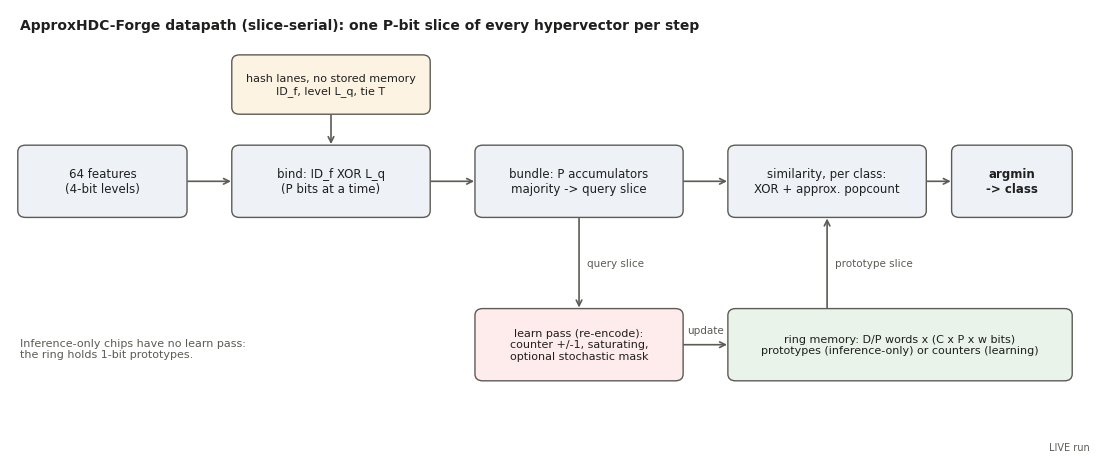

In [3]:
# @title Architecture diagram
from matplotlib.patches import FancyBboxPatch
INK, MUTE = "#1f1f1e", "#5c5b55"
fig, ax = plt.subplots(figsize=(11, 4.6)); ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0.4, 5.4)
def box(x, y, w, h, text, fc="#eef1f6", fs=8.5, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec=MUTE, lw=1))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK, fontweight="bold" if bold else None)
def arrow(x0, y0, x1, y1, label=None, dx=0.08, dy=0.0):
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="->", color=MUTE, lw=1.2))
    if label: ax.text((x0 + x1) / 2 + dx, (y0 + y1) / 2 + dy, label, fontsize=7.5, color=MUTE, va="center", ha="left" if dx else "center")
# row 1: the classification path
box(0.1, 3.0, 1.7, 0.8, "64 features\n(4-bit levels)")
box(2.3, 3.0, 2.0, 0.8, "bind: ID_f XOR L_q\n(P bits at a time)")
box(4.8, 3.0, 2.1, 0.8, "bundle: P accumulators\nmajority -> query slice")
box(7.4, 3.0, 2.0, 0.8, "similarity, per class:\nXOR + approx. popcount")
box(9.7, 3.0, 1.2, 0.8, "argmin\n-> class", bold=True)
box(2.3, 4.2, 2.0, 0.65, "hash lanes, no stored memory\nID_f, level L_q, tie T", fc="#fdf3e3", fs=8)
arrow(1.8, 3.4, 2.3, 3.4); arrow(4.3, 3.4, 4.8, 3.4); arrow(6.9, 3.4, 7.4, 3.4); arrow(9.4, 3.4, 9.7, 3.4)
arrow(3.3, 4.2, 3.3, 3.8)
# row 2: state and learning
box(4.8, 1.1, 2.1, 0.8, "learn pass (re-encode):\ncounter +/-1, saturating,\noptional stochastic mask", fc="#fdeceb", fs=8)
box(7.4, 1.1, 3.5, 0.8, "ring memory: D/P words x (C x P x w bits)\nprototypes (inference-only) or counters (learning)", fc="#e9f3ea", fs=8)
arrow(5.85, 3.0, 5.85, 1.9, "query slice")
arrow(6.9, 1.5, 7.4, 1.5, "update", dx=0, dy=0.17)
arrow(8.4, 1.9, 8.4, 3.0, "prototype slice")
ax.text(0.1, 5.3, "ApproxHDC-Forge datapath (slice-serial): one P-bit slice of every hypervector per step", fontsize=10, fontweight="bold", color=INK, va="top")
ax.text(0.1, 1.45, "Inference-only chips have no learn pass:\nthe ring holds 1-bit prototypes.", fontsize=8, color=MUTE, va="center")
fig.text(0.995, 0.005, "LIVE run", ha="right", va="bottom", fontsize=7, color=MUTE)
plt.tight_layout(); plt.show()

### 3.2 Why it works: similar windows get similar hypervectors

Below, we encode real UCI-HAR windows (dimension 1024) and compare Hamming distances between pairs of windows of the **same activity** and of **different activities**. This is the whole principle that HDC relies on.

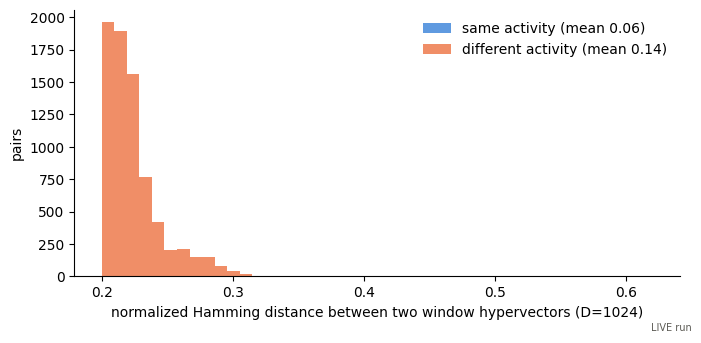

In [4]:
# @title Same-class vs different-class distances (real data)
d = data.load(F=64, Q=16)                                  # downloads UCI-HAR (checksum-verified) the first time
im = H.item_memory(64, 16, seed=0)
Xtr, ytr, str_ = d["train"]
idx = np.random.default_rng(0).choice(len(ytr), 800, replace=False)
Qs = H.encode(Xtr[idx], im)[:, :1024].astype(np.int8)
ys = ytr[idx]
rng = np.random.default_rng(1)
a, b = rng.integers(0, len(idx), (2, 40000))
dist = (Qs[a] != Qs[b]).mean(1)
same = ys[a] == ys[b]
fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.linspace(0.2, 0.62, 45)
ax.hist(dist[same], bins, alpha=0.75, color="#2a78d6", label=f"same activity (mean {dist[same].mean():.2f})")
ax.hist(dist[~same], bins, alpha=0.75, color="#eb6834", label=f"different activity (mean {dist[~same].mean():.2f})")
ax.set_xlabel("normalized Hamming distance between two window hypervectors (D=1024)"); ax.set_ylabel("pairs")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.text(0.995, 0.005, "LIVE run", ha="right", va="bottom", fontsize=7, color="#5c5b55"); plt.tight_layout(); plt.show()

## 4. Data, split and evaluation protocol

**Dataset.** UCI-HAR (Anguita et al., 2013): smartphone inertial windows, 6 activities, 561 features, 30 subjects. We use the official **subject-wise split** (21 training subjects, 9 test subjects) and carve 4 validation subjects out of the training subjects with a fixed seed (`data/splits.json`). **No subject appears in two splits**, which matters because UCI-HAR windows overlap by 50%.

**Features.** 64 features selected by ANOVA F-score with a correlation filter, then quantized to 16 levels with min/max from the training subjects only. Everything that touches labels or statistics is fit on training subjects only.

**Two kinds of numbers, never mixed.** All design decisions (search objectives, model selection) use the *validation* subjects. All *final* numbers (Section 12) use the 9 *test* subjects, which no decision ever saw.

**Streaming protocol (test-then-train).** For adaptation experiments, each subject's windows are split in time per activity: the first 70% form the stream, the last 30% are held out and never learned, with a 2-window gap because of window overlap. A stream sample is *classified first, then learned*, never the other way round. Labels are assumed to arrive with the data (a calibration phase or user feedback): this is **supervised** online learning.

In [5]:
# @title Subject-wise split
sp = json.load(open("data/splits.json"))
print({k: sp[k] for k in ("train_subjects", "val_subjects", "test_subjects")})
for name in ("train", "val", "test"):
    X, y, s = d[name]
    print(f"{name:5s}: {X.shape[0]:5d} windows, {len(set(s.tolist())):2d} subjects, class counts {np.bincount(y).tolist()}")
assert not (set(sp["train_subjects"]) & set(sp["test_subjects"])) and not (set(sp["val_subjects"]) & set(sp["test_subjects"]))
print("selected feature indices (first 12):", d["features"][:12].tolist(), "...")

{'train_subjects': [3, 6, 7, 8, 11, 14, 16, 17, 21, 22, 23, 25, 26, 27, 28, 29, 30], 'val_subjects': [1, 5, 15, 19], 'test_subjects': [2, 4, 9, 10, 12, 13, 18, 20, 24]}
train:  6015 windows, 17 subjects, class counts [969, 885, 809, 1063, 1139, 1150]
val  :  1337 windows,  4 subjects, class counts [257, 188, 177, 223, 235, 257]
test :  2947 windows,  9 subjects, class counts [496, 471, 420, 491, 532, 537]
selected feature indices (first 12): [40, 366, 268, 233, 269, 244, 509, 100, 182, 423, 89, 284] ...


## 5. The bit-accurate golden model and its algorithmic results

### 5.1 What "bit-accurate" means here

`src/hdc_model.py` defines every operation so that the RTL can reproduce it **bit for bit**. Key definitions (all with tie rules fixed):

* **Rematerialized vectors.** Bit `j` of a random vector is bit `j mod 32` of `mix32(key(seed, tag, feature, j div 32))`, where `mix32` uses only shifts, XORs and two constant adds. Because the hash is keyed by the *global* bit index, a design with dimension `D` is exactly the first `D` bits of a larger design, and the slice width `P` never changes the arithmetic, only area and latency.
* **Level vectors** flip `bitrev(j) < q*2048/(Q-1)` bits of a base vector, so neighbouring levels are similar and extreme levels are nearly orthogonal.
* **Encoding** bundles `F` bound vectors by majority; ties take a fixed tie-break vector. Classification takes the nearest prototype; ties go to the lowest class index.
* **Learning** keeps signed saturating counters of `w` bits (bipolar updates); the prototype bit is 1 if the counter is positive, 0 if negative, and the tie-break bit at zero.
* **Four similarity units** (the approximation knobs): `exact` popcount; `trunc(t)` drops `t` LSBs of each 8-bit group count; `satcomp(b)` clips each group count to `2^b - 1` (a saturating compressor); `sampled(k)` compares only the first `k/8` of the dimensions.
* **Optional stochastic update:** each counter moves with probability `2^-k`, using a hash-derived mask. This lets very narrow counters learn without saturating.

In [6]:
# @title The learning rule and similarity units, as code
import inspect
print(inspect.getsource(H.Similarity)); print(inspect.getsource(H.OnlineLearner.step))

@dataclass(frozen=True)
class Similarity:
    variant: str = "exact"
    knob: int = 0

    def lut(self):
        _, _, g = VARIANTS[self.variant]
        return g(_PC8, self.knob).astype(np.int32)

    def n_groups(self, D):
        return D // 8 * self.knob // 8 if self.variant == "sampled" else D // 8

    def distance(self, qp, protop):
        """qp [..., D/8], protop [C, D/8] packed -> distances [..., C]."""
        G = self.n_groups(protop.shape[-1] * 8)
        x = qp[..., None, :G] ^ protop[:, :G]
        return self.lut()[x].sum(-1)

    def __str__(self):
        return self.variant if self.variant == "exact" else f"{self.variant}({self.knob})"

    def step(self, q, qp, y):
        """Test-then-train on one sample: predict with current prototypes, then learn."""
        pred = int(classify(qp, self.protop, self.sim))
        if self.mode == "bundle":
            self._add(y, self._bipolar(q))
        elif pred != y:
            b = self._bipolar(q)
            self._add(y,

### 5.2 Mini sweep, live

The full sweep (5 seeds, 5 dimensions, 5 learning recipes, 10 similarity units) took 70 s on 14 cores and is replayed below. Here is a small live version (1 seed, 3 dimensions) so you can watch the model train. *Error-driven* learning updates only on mistakes (add to the true class, subtract from the predicted one), after one bundle-all warm-up pass.

In [7]:
# @title Mini accuracy-vs-D sweep (LIVE)
if RUN_LIVE_ALGO:
    seed, rows = 0, []
    im0 = H.item_memory(64, 16, seed)
    Qtr, Qva = H.encode(d["train"][0], im0), H.pack(H.encode(d["val"][0], im0))
    t0 = time.time()
    for D in (256, 512, 1024):
        for label, mode, w in (("bundle-all, w=16", "bundle", 16), ("error-driven, w=8", "error", 8)):
            L = H.train(Qtr, d["train"][1], D, w, mode, im0.T, H.Similarity(), 0, seed)
            rows.append(dict(D=D, recipe=label, val_acc=round(float((L.predict(Qva[:, :D // 8]) == d["val"][1]).mean()), 3)))
    print(f"{time.time() - t0:.0f}s"); display(pd.DataFrame(rows).pivot(index="D", columns="recipe", values="val_acc"))

2s


recipe,"bundle-all, w=16","error-driven, w=8"
D,,
256,0.669,0.652
512,0.727,0.796
1024,0.731,0.848


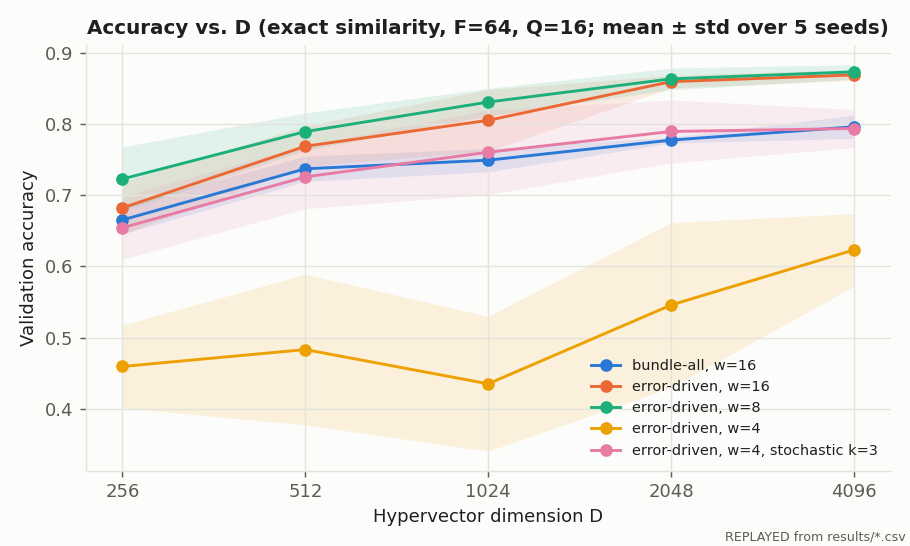

In [8]:
# @title Accuracy vs. dimension (REPLAYED, 5 seeds)
E1.plot_all(live=False)      # re-plots every Section-5 figure from results/*.csv, tagged REPLAYED
show("day1_acc_vs_D.png", 760)

**Reading the figure.** Accuracy grows with `D` and saturates around 2048. Error-driven learning with 8-bit counters beats bundle-all by 5 to 8 points. **Narrow 4-bit counters collapse** (about 0.44 at D=1024), because the counters saturate and the prototypes freeze; adding the stochastic update (`k=3`) restores most of the accuracy (about 0.76). This is the first sign that, for learning, *counter design* matters more than anything else.

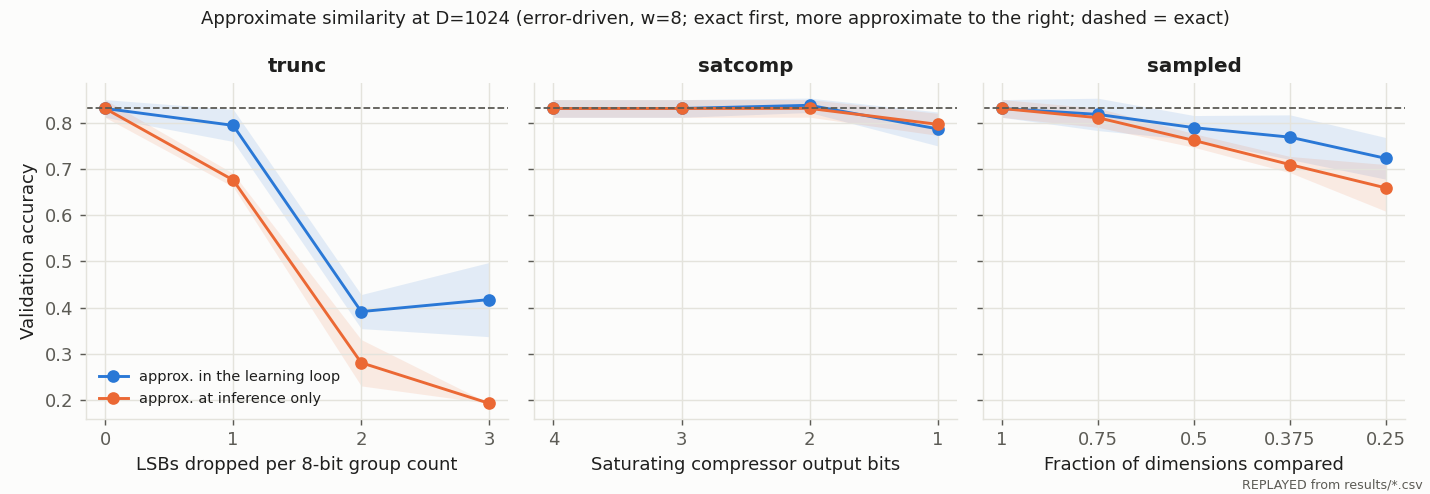

In [9]:
# @title Accuracy vs. approximation level (REPLAYED)
show("day1_acc_vs_approx.png", 1000)

**Reading the figure.** Dropping bits (`trunc`) hurts quickly, because each 8-bit group count is already small. The saturating compressor (`satcomp`) loses almost nothing down to 2 output bits. Letting the learner see the approximation (blue, learning *in the loop*) beats applying it only at inference (orange) everywhere it matters: **training with the approximate hardware compensates for it**, the HDC counterpart of fine-tuning a quantized network.

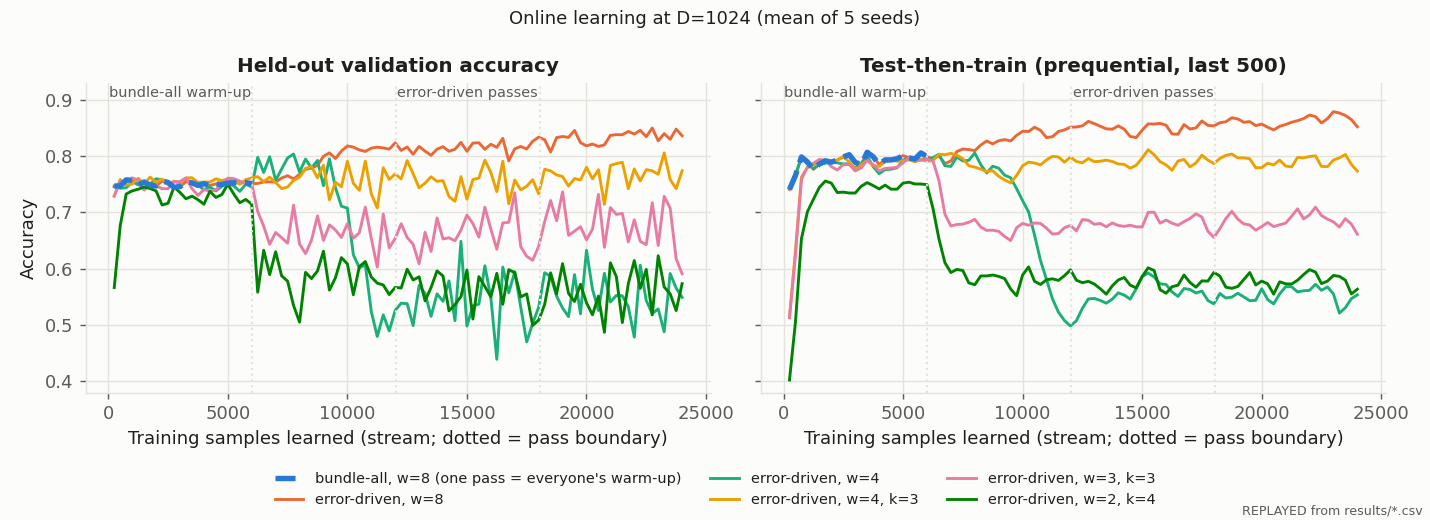

In [10]:
# @title Accuracy vs. samples learned (REPLAYED)
show("day1_acc_vs_samples.png", 1000)

**Reading the figure.** The dashed curve is the shared warm-up pass. Error-driven learning with 8-bit counters keeps improving over later passes; narrower counters degrade after the warm-up (saturation), and the stochastic update (`k=3` or `k=4`) delays that, though not completely at 2-3 bits. The right panel is the strict test-then-train accuracy over the stream.

### 5.3 Is approximating the similarity unit worth it?

This is the question a skeptical reader should ask first. The *sampled* variant is equivalent to simply using a smaller `D`. So the honest baseline is **exact popcount with a smaller D at equal area**. The figure plots accuracy against estimated cell area (Yosys + sky130 block synthesis), exact-popcount designs as the baseline curve, approximate variants as dots.

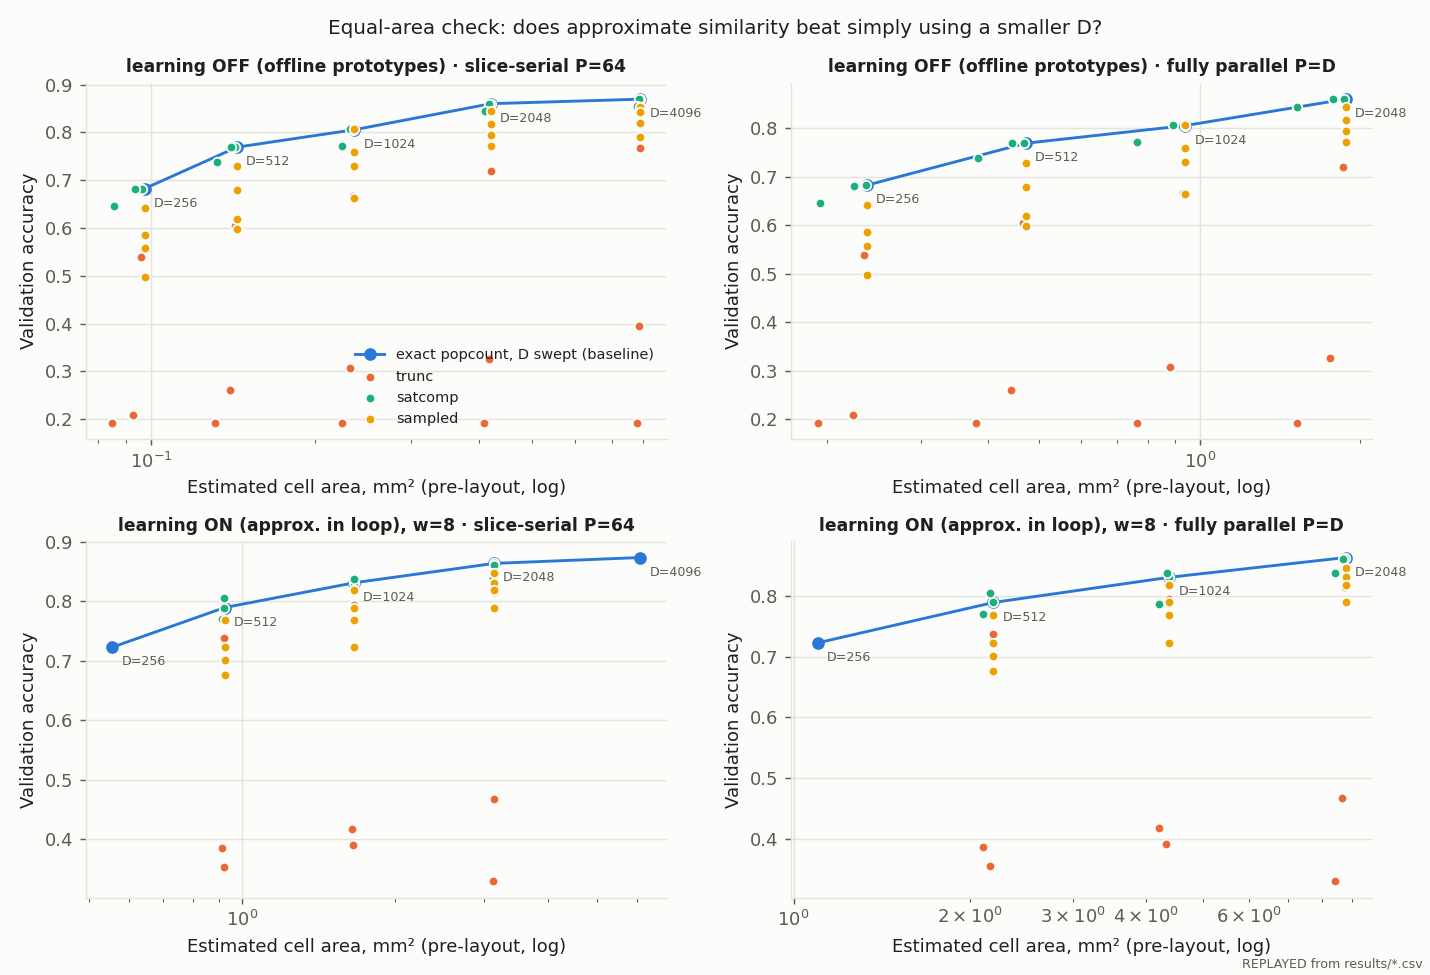

In [11]:
# @title Equal-area check (REPLAYED)
show("day1_equal_area.png", 1000)

**Reading the figure.** The approximate variants sit **on** the exact-popcount baseline curve, not above it: the best of them (`satcomp`) matches the baseline within a percent or two of area. The reason is in the next figure (a Yosys block-level estimate, before layout, counting a stored bit as a flip-flop plus its select mux): for a slice-serial (P=64) learning chip with 8-bit counters the prototype/counter storage is about **89% of the area and the similarity unit about 1%**. (The fully parallel P=1024 design in the right half of the figure instead pays for a huge counter-update array, which is why we use the slice-serial datapath.) Section 7.1 checks the storage claim against real layouts. **We therefore treat approximation of the similarity unit as a small, honest result, and approximation of the storage (counter width, stochastic update) as the large one.**

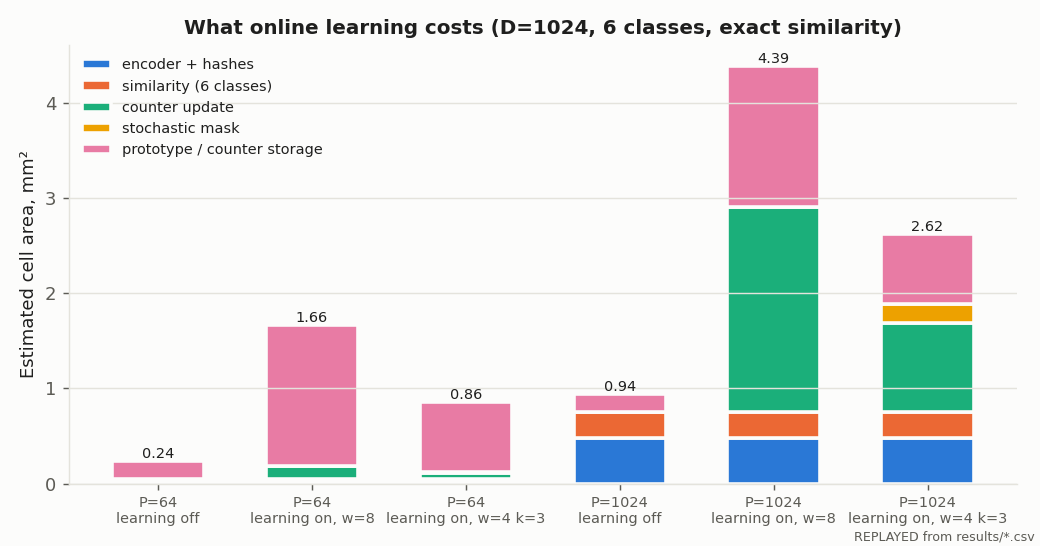

In [12]:
# @title Where the area goes (REPLAYED)
show("day1_area_breakdown.png", 760)

## 6. RTL generation and verification

### 6.1 The generator

`src/rtlgen.py` emits synthesizable Verilog-2005 for any legal configuration: dimension `D`, slice width `P`, features `F`, levels `Q`, classes `C`, similarity variant and knob, learning mode (off / bundle-all / error-driven), counter width `w`, stochastic exponent `k`, a hash seed, and an optional **clock-gated ring memory** (`cg=1`, Section 8.3). Learning-off designs have no counters at all (the ring stores 1-bit prototypes). A thin *chip top* adds a narrow staged load port so the physical design has about 40 pins instead of about 1,700. Here is chip A's core, generated live.

In [13]:
# @title Generate chip A's RTL (LIVE)
cfgA = rtlgen.RTLConfig(D=512, P=32, variant="satcomp", knob=2, learn=1, w=2, k=0)
vA = rtlgen.generate_chip(cfgA)
print(cfgA)
print(f"{len(vA.splitlines())} lines of Verilog\n")
print("\n".join(vA.splitlines()[:30]))

RTLConfig(D=512, P=32, F=64, Q=16, C=6, variant='satcomp', knob=2, learn=1, w=2, k=0, seed=0, cg=0)
251 lines of Verilog

// Generated by rtlgen.py -- do not edit. Config: {"D": 512, "P": 32, "F": 64, "Q": 16, "C": 6, "variant": "satcomp", "knob": 2, "learn": 1, "w": 2, "k": 0, "seed": 0, "cg": 0}
`default_nettype none
module approxhdc_top (
  input  wire              clk,
  input  wire              rst,
  input  wire              start,
  input  wire              learn,
  input  wire              upd_err,
  input  wire [2:0]        label,
  input  wire              feat_we,
  input  wire [5:0]   feat_addr,
  input  wire [3:0]   feat_data,
  input  wire              load_we,
  input  wire              rot,
  input  wire [383:0]   load_data,
  output wire [383:0]   head,
  output wire              busy,
  output reg               done,
  output reg  [2:0]        pred,
  output reg               learned,
  output wire [59:0] dist_flat,
  output wire [31:0]    dbg_q,
  output wire        

### 6.2 Verification: the RTL must match the model, bit for bit

The cocotb testbench runs the golden model in lock step with the RTL and compares, **for every sample**: the `P` query bits of every slice (both passes), all class distances, the prediction, whether a learning update happened, and, for learning designs, **every counter** every 10 samples. Stimulus: random vectors, 50 real UCI-HAR windows, test-then-train streams, and directed tests (counters pinned at both saturation rails, zero counters and the tie vector, argmin ties, error-driven "no update" when the prediction is right).

The matrix covers every similarity variant, bundle-all and error-driven learning, counter widths 2 to 8, stochastic exponents 0 to 4, approximation in the learning loop, slice widths 32/64/128, a fully parallel `P=D` design, an odd feature count (no bundling ties), a different hash seed, and **clock-gated variants** of the final-chip styles (including the single-word-ring corner `P=D`).

In [14]:
# @title Verification matrix (REPLAYED)
v = pd.read_csv("results/verification_verilator.csv")
print(f"Verilator: {int((v.failed == 0).sum())}/{len(v)} configurations pass; tests run per configuration: 5 (random, real, learning stream, saturation, reset/ties)")
display(v[["config", "tests", "failed", "seconds"]])
c = pd.read_csv("results/verification_chip_verilator.csv"); print(f"\nChip top (staged load port): {int((c.failed == 0).sum())}/{len(c)} configurations pass")
import os
if os.path.exists("results/verification_icarus.csv"):
    i = pd.read_csv("results/verification_icarus.csv"); print(f"Icarus Verilog (4-state) cross-check: {int((i.failed == 0).sum())}/{len(i)} configurations pass")

Verilator: 28/28 configurations pass; tests run per configuration: 5 (random, real, learning stream, saturation, reset/ties)


,config,tests,failed,seconds
0,hdc_D512_P64_F64_Q16_exact0_L0,5,0,21.1
1,hdc_D512_P64_F64_Q16_trunc1_L0,5,0,19.1
2,hdc_D512_P64_F64_Q16_trunc2_L0,5,0,18.9
3,hdc_D512_P64_F64_Q16_trunc3_L0,5,0,19.1
4,hdc_D512_P64_F64_Q16_satcomp3_L0,5,0,18.9
5,hdc_D512_P64_F64_Q16_satcomp2_L0,5,0,19.5
6,hdc_D512_P64_F64_Q16_satcomp1_L0,5,0,23.6
7,hdc_D512_P64_F64_Q16_sampled6_L0,5,0,19.3
8,hdc_D512_P64_F64_Q16_sampled4_L0,5,0,18.0
9,hdc_D512_P64_F64_Q16_sampled2_L0,5,0,17.7



Chip top (staged load port): 6/6 configurations pass
Icarus Verilog (4-state) cross-check: 28/28 configurations pass


### 6.3 Does the testbench actually catch bugs?

A passing testbench proves little unless it fails on broken RTL. `tb/mutation_test.py` injects seven known bugs into the generated Verilog (four in the learning datapath, three in the clock gating) and checks that cocotb fails on each, while the unmodified control passes. One of them, skipping the ring's power-up clear, is invisible to Verilator (a 2-state simulator that starts every register at 0), so that mutant runs on Icarus (4-state), where it is caught; this is one reason both simulators are used.

In [15]:
# @title Injected-bug check (REPLAYED)
display(pd.read_csv("results/mutation_test.csv"))

,mutant,simulator,tests,failed,expected,result
0,control (unmodified),verilator,5,0,pass,OK
1,binarize ignores the tie vector,verilator,5,5,fail,OK
2,counter saturation off by one,verilator,5,2,fail,OK
3,stochastic-update mask ignored,verilator,5,2,fail,OK
4,argmin ties go to the highest class,verilator,5,4,fail,OK
5,gating: load/readout shifts forgotten,verilator,5,4,fail,OK
6,gating: ring clock gated off during CLEAR,icarus,5,1,fail,OK
7,gating: ring clock never gated (always shifts),verilator,5,4,fail,OK


In [16]:
# @title Optional: re-run a small verification (LIVE)
if RUN_RTL_VERIFICATION:
    # LIVE: a reduced cocotb verification with Icarus Verilog (apt install needed in Colab)
    if IN_COLAB: subprocess.run("apt-get -qq install -y iverilog > /dev/null", shell=True, check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "cocotb==2.1.0"], check=True)
    r = subprocess.run([sys.executable, "tb/run_verif.py", "--quick", "--sim", "icarus"], capture_output=True, text=True)
    print("\n".join(l for l in r.stdout.splitlines() if l.startswith(("PASS", "FAIL")) or "configurations" in l))
else:
    print("RUN_RTL_VERIFICATION is False: showing the saved results above. Set it to True to re-run a small verification.")

RUN_RTL_VERIFICATION is False: showing the saved results above. Set it to True to re-run a small verification.


## 7. Physical implementation: RTL to GDS on sky130

`src/flow_runner.py` turns a design configuration into a layout and a metrics row. It generates the chip RTL, runs **LibreLane 3.0.14** (Yosys, OpenROAD, Magic, KLayout, Netgen, OpenSTA) in its pinned Docker image on sky130A (`sky130_fd_sc_hd`), with a 20 ns (50 MHz) clock, 45% core utilization and 55% placement density, and appends one row to `results/flow_runs.csv`. DRC and timing problems are *recorded*, not allowed to abort a run, so every run produces a row. The batch used a *fast* mode (nominal-voltage corners, no Magic DRC); the three final chips use the *full* sign-off flow, including Magic DRC and LVS.

**Result: 37 layouts (34 conventional and 3 clock-gated, Section 8.3), all with a GDS and a clean KLayout DRC, LVS and routing DRC**, covering D = 256, 512, 1024, slice widths 32, 64, 128, all four similarity units, and learning off / bundle-all / error-driven with counter widths 2 to 8.

In [17]:
# @title All real flow results (REPLAYED)
fr_all = pd.read_csv("results/flow_runs.csv"); fr_all = fr_all[fr_all.gds.notna()].copy()
fr_all["cg"] = fr_all["cg"].fillna(0).astype(int)
fr_all["cells_mm2"] = fr_all.cell_area_um2 / 1e6; fr_all["flops"] = fr_all.seq_count
fr = fr_all[fr_all.cg == 0].copy()        # conventional layouts: the cost analysis in this section
gated = fr_all[fr_all.cg == 1].copy()     # the three clock-gated final chips: Section 8.3
print(f"{len(fr_all)} layouts = {len(fr)} conventional + {len(gated)} clock-gated; sign-off clean (KLayout DRC, LVS, routing DRC = 0): {int(fr_all.signoff_clean.sum())}")
print(f"typical-corner setup slack at 50 MHz, conventional layouts: min {fr.setup_ws_tt_ns.min():.2f} ns (all meet 50 MHz at the typical corner)")
print(f"slow corner (ss, 100C, 1.60 V), conventional layouts: {int((fr.setup_ws_ss_ns >= 0).sum())}/{len(fr)} meet 50 MHz; slow-corner Fmax median {fr.fmax_ss_mhz.median():.0f} MHz")
cols = ["D", "P", "variant", "knob", "learn", "w", "k", "mode", "cells_mm2", "flops", "setup_ws_tt_ns", "setup_ws_ss_ns", "runtime_s"]
display(fr.sort_values(["learn", "D", "P"])[cols].round(3).reset_index(drop=True))

37 layouts = 34 conventional + 3 clock-gated; sign-off clean (KLayout DRC, LVS, routing DRC = 0): 37
typical-corner setup slack at 50 MHz, conventional layouts: min 4.20 ns (all meet 50 MHz at the typical corner)
slow corner (ss, 100C, 1.60 V), conventional layouts: 0/34 meet 50 MHz; slow-corner Fmax median 43 MHz


,D,P,variant,knob,learn,w,k,mode,cells_mm2,flops,setup_ws_tt_ns,setup_ws_ss_ns,runtime_s
0,256,32,sampled,4,0,8,0,fast,0.152,2289.0,9.361,-0.990,1558
1,256,32,exact,0,0,8,0,fast,0.151,2289.0,8.613,-1.771,1571
2,256,32,trunc,1,0,8,0,fast,0.149,2289.0,8.949,-1.211,1206
3,256,64,exact,0,0,8,0,fast,0.197,2704.0,7.036,-1.486,2016
4,512,32,exact,0,0,8,0,fast,0.233,3832.0,7.271,-1.611,1555
5,512,32,satcomp,2,0,8,0,fast,0.230,3832.0,7.843,-1.470,1756
6,512,64,exact,0,0,8,0,fast,0.281,4247.0,8.067,-2.034,2234
7,512,64,trunc,1,0,8,0,fast,0.277,4247.0,8.704,-1.799,2137
8,1024,32,exact,0,0,8,0,fast,0.397,6911.0,7.923,-1.278,3914
9,1024,32,satcomp,2,0,8,0,full,0.394,6911.0,5.892,-3.115,3578


### 7.1 What does on-chip learning cost? Matched pairs from real layouts

Each row compares a learning-capable chip with the inference-only chip of the **same dimension, slice width and similarity unit** (the "off" column). This is the learning-on vs learning-off comparison, from real sky130 layouts.

,D,P,variant,knob,mode_,w,k,off_mm2,cells_mm2,area_ratio
0,256,32,exact,0,error-driven,4,3,0.151,0.500,3.315
1,256,32,exact,0,error-driven,8,0,0.151,0.922,6.109
2,256,64,exact,0,error-driven,4,3,0.197,0.660,3.344
3,256,64,exact,0,error-driven,8,0,0.197,1.187,6.014
4,512,32,satcomp,2,bundle-all,2,0,0.230,0.426,1.849
5,512,32,satcomp,2,error-driven,3,3,0.230,0.631,2.740
6,512,32,exact,0,error-driven,4,3,0.233,0.826,3.538
7,512,32,exact,0,error-driven,8,0,0.233,1.564,6.697
8,512,64,exact,0,error-driven,4,3,0.281,0.983,3.492
9,512,64,exact,0,bundle-all,7,0,0.281,1.604,5.698


learning-capable vs inference-only area: 1.85x to 6.70x (median 3.59x)


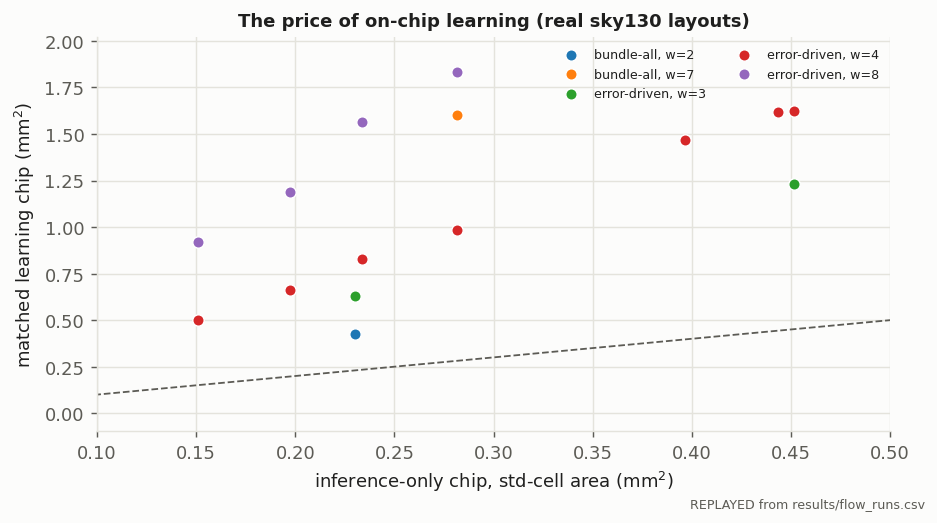

In [18]:
# @title Learning-on vs learning-off area, matched pairs (REPLAYED)
off = fr[fr.learn == 0].set_index(["D", "P", "variant", "knob"]).cells_mm2
pairs = fr[fr.learn > 0].copy()
pairs["off_mm2"] = [off.get((r.D, r.P, r.variant, r.knob), np.nan) for r in pairs.itertuples()]
pairs = pairs.dropna(subset=["off_mm2"]); pairs["area_ratio"] = pairs.cells_mm2 / pairs.off_mm2
pairs["mode_"] = pairs.learn.map({1: "bundle-all", 2: "error-driven"})
display(pairs.sort_values(["D", "P", "w"])[["D", "P", "variant", "knob", "mode_", "w", "k", "off_mm2", "cells_mm2", "area_ratio"]].round(3).reset_index(drop=True))
print(f"learning-capable vs inference-only area: {pairs.area_ratio.min():.2f}x to {pairs.area_ratio.max():.2f}x (median {pairs.area_ratio.median():.2f}x)")
fig, ax = plt.subplots(figsize=(7.2, 4))
for (m, w), g in pairs.groupby(["mode_", "w"]):
    ax.scatter(g.off_mm2, g.cells_mm2, s=40, label=f"{m}, w={w}", edgecolor="white", linewidth=0.8, zorder=3)
lim = [0, pairs.cells_mm2.max() * 1.05]; ax.plot(lim, lim, "--", color="#5c5b55", lw=1); ax.set_xlim(0.1, 0.5)
ax.set_xlabel("inference-only chip, std-cell area (mm$^2$)"); ax.set_ylabel("matched learning chip (mm$^2$)")
ax.set_title("The price of on-chip learning (real sky130 layouts)", fontsize=10); ax.legend(fontsize=7, frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False); fig.text(0.995, 0.005, "REPLAYED from results/flow_runs.csv", ha="right", va="bottom", fontsize=7, color="#5c5b55")
plt.tight_layout(); plt.show()

**Reading the table.** Learning hardware costs between roughly **1.9x and 6.7x** the area of the matching inference-only chip. The spread is the counter width: wide counters with the error-driven rule are the most expensive; **2-bit bundle-all counters (chip A) cost only 1.85x**. The cost is the *storage*: a `w`-bit counter per bit per class instead of one prototype bit, plus the per-class update logic.

### What is the area made of? (real layouts)

In a finished layout, flip-flops are only about a third of the standard-cell area; the rest is the logic and buffers that surround them. So "storage dominates" needs a measurement that does not depend on cell classes. We fit the real areas of all 34 layouts against the number of stored ring bits `C x D x w` (`C x D` for inference-only chips) and the slice width `P` (non-negative least squares). This is an in-sample fit, used only to *attribute* area, not to predict it.

In [19]:
# @title What the area is made of (REPLAYED)
from scipy.optimize import nnls
fr["bits"] = 6 * fr.D * np.where(fr.learn > 0, fr.w, 1)
X = np.c_[fr.bits, fr.P * (fr.learn > 0), fr.P, np.ones(len(fr))]; yv = fr.cell_area_um2.values
coef, _ = nnls(X, yv); pred = X @ coef
share = (X * coef).sum(0) / pred.sum()
print(f"in-sample fit error {np.mean(np.abs(pred - yv) / yv):.1%}   (n={len(fr)} layouts)")
print(f"area attributed to stored bits: {share[0]:.0%} at {coef[0]:.0f} um2 per stored bit (a bare sky130 flip-flop is 20 um2)")
print(f"area that scales with slice width P (encoder/similarity/update lanes): {share[1] + share[2]:.0%}; fixed: {share[3]:.0%}")
g = fr.assign(ff=fr.seq_area_um2 / fr.cell_area_um2, logic=fr.comb_area_um2 / fr.cell_area_um2, buf=fr.buf_area_um2 / fr.cell_area_um2, clk=fr.clk_buf_area_um2 / fr.cell_area_um2)
print("\nshare of std-cell area by cell class (median over layouts):")
display(g.groupby(g.learn > 0)[["ff", "logic", "buf", "clk"]].median().rename(index={False: "inference-only", True: "learning"}, columns={"ff": "flip-flops", "logic": "logic", "buf": "timing/fanout buffers", "clk": "clock tree"}).round(2))

in-sample fit error 6.2%   (n=34 layouts)
area attributed to stored bits: 77% at 58 um2 per stored bit (a bare sky130 flip-flop is 20 um2)
area that scales with slice width P (encoder/similarity/update lanes): 20%; fixed: 3%

share of std-cell area by cell class (median over layouts):


,flip-flops,logic,timing/fanout buffers,clock tree
learn,,,,
inference-only,0.34,0.35,0.25,0.03
learning,0.33,0.34,0.26,0.03


**Reading the result.** Roughly **three quarters of the area scales with the number of stored bits**, at about 60 um^2 per bit: three times a bare flip-flop, because every ring bit brings its select multiplexer and its share of the timing and hold buffers on the shift chain. The split by cell class is almost the same for learning and inference-only chips, which is exactly what you expect when the whole design grows with its state. This is why counter width, not arithmetic, is the lever.


### 7.2 The three final chips (conventional implementation)

After the search (Section 9) we ran three Pareto designs through the **full sign-off flow**, first as conventional designs here and then with a clock-gated ring memory (Section 8.3) (Magic DRC, KLayout DRC, LVS, routing DRC, antenna checks):

| Chip | Configuration | Role |
|---|---|---|
| **A** | D=512, P=32, `satcomp(2)`, bundle-all learning, 2-bit counters | the final chip (also built clock-gated, Section 8.3) |
| **B** | D=1024, P=32, `satcomp(2)`, **learning off** | matched inference-only comparison |
| **C** | D=256, P=32, `satcomp(2)`, bundle-all learning, 2-bit counters | smallest learning chip |

In [20]:
# @title Final chips: sign-off results (REPLAYED)
full = fr[fr["mode"] == "full"].copy()
names = {(512, 1): "A", (1024, 0): "B", (256, 1): "C"}
full["chip"] = [names.get((r.D, r.learn)) for r in full.itertuples()]
fin = full.dropna(subset=["chip"]).set_index("chip").sort_index()
t = pd.DataFrame({"std-cell area (mm2)": fin.cells_mm2.round(3), "core (mm2)": (fin.core_area_um2 / 1e6).round(3),
                  "flip-flops": fin.seq_count.astype(int), "slack @50MHz, typical (ns)": fin.setup_ws_tt_ns.round(2),
                  "Fmax typical (MHz)": fin.fmax_tt_mhz.round(0), "Fmax slow corner (MHz)": fin.fmax_ss_mhz.round(0),
                  "Magic DRC": fin.magic_drc.astype(int), "KLayout DRC": fin.klayout_drc.astype(int), "LVS errors": fin.lvs_errors.astype(int),
                  "route DRC": fin.route_drc.astype(int), "hold violations": fin.hold_vio_count.astype(int), "flow time (min)": (fin.runtime_s / 60).round(0)})
display(t.T)

chip,A,B,C
std-cell area (mm2),0.426,0.394,0.261
core (mm2),0.619,0.572,0.392
flip-flops,7102.000,6911.000,4023.000
"slack @50MHz, typical (ns)",5.790,5.890,6.670
Fmax typical (MHz),70.000,71.000,75.000
Fmax slow corner (MHz),42.000,43.000,44.000
Magic DRC,0.000,0.000,0.000
KLayout DRC,0.000,0.000,0.000
LVS errors,0.000,0.000,0.000
route DRC,0.000,0.000,0.000


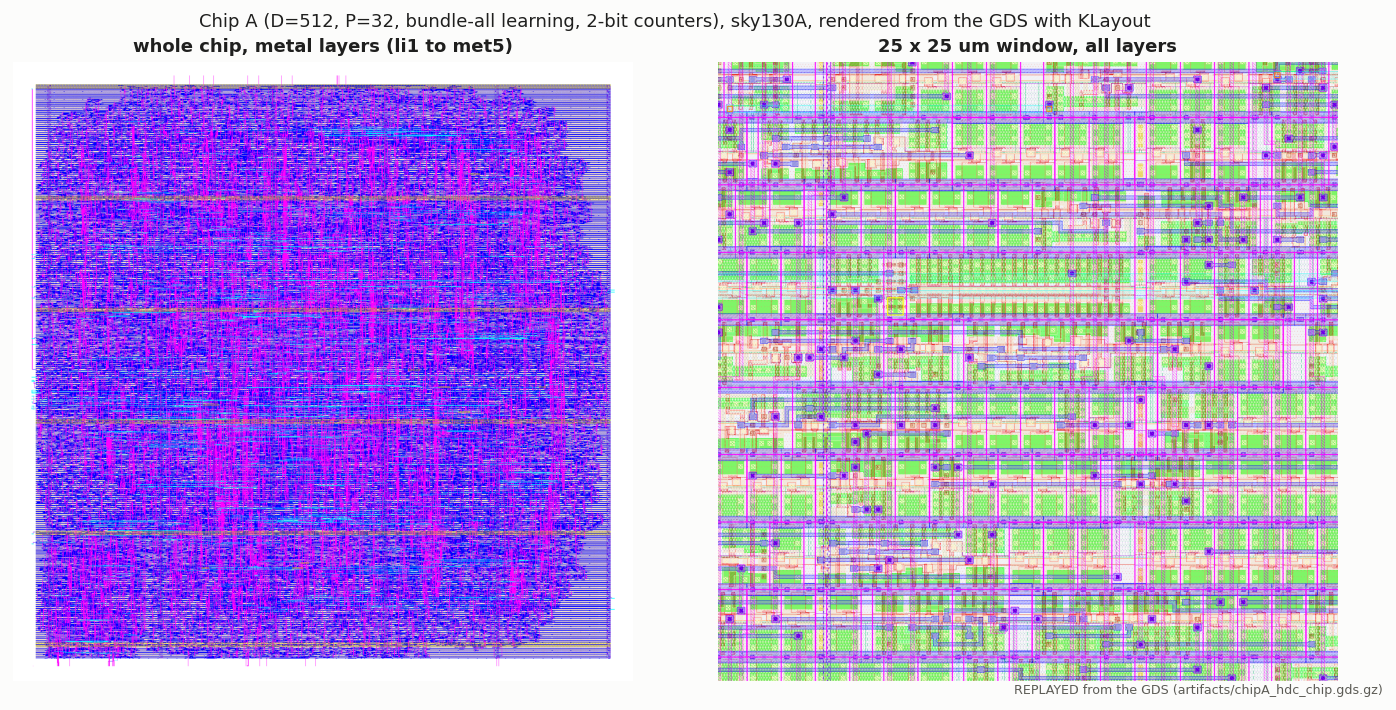

In [21]:
# @title Chip A layout
fig, axs = plt.subplots(1, 2, figsize=(11, 5.4))
for ax, f, t in zip(axs, ("chipA_layout_full.png", "chipA_layout_zoom.png"),
                    ("whole chip, metal layers (li1 to met5)", "25 x 25 um window, all layers")):
    ax.imshow(plt.imread(FIGS / f)); ax.set_title(t, fontsize=10); ax.axis("off")
fig.suptitle("Chip A (D=512, P=32, bundle-all learning, 2-bit counters), sky130A, rendered from the GDS with KLayout", fontsize=10)
fig.text(0.995, 0.005, "REPLAYED from the GDS (artifacts/chipA_hdc_chip.gds.gz)", ha="right", va="bottom", fontsize=7, color="#5c5b55")
plt.tight_layout(); plt.show()

**Timing, stated plainly.** All three chips meet the 50 MHz target with margin at the **typical** corner (+5.8 ns slack, Fmax about 70 MHz). At the slow corner (ss, 100 C, 1.60 V) setup slack is negative, which limits Fmax to about 42 MHz; hold timing is clean on A, B and C. We did not iterate the clock constraint to close the slow corner, and report it so you can. (The clock-gated versions in Section 8.3 improve every one of these numbers.)

### 7.3 Run the flow yourself, in Colab (optional)

Colab has no Docker, so the Colab path installs the same LibreLane version with Nix, using the setup cells from LibreLane's own notebook (Apache-2.0, referenced below). `flow_runner.py` then runs with `HDC_FLOW_NATIVE=1`. The only fix needed was to hand LibreLane a small `yosys` wrapper that pins the embedded Python's home to the Nix Python (LibreLane's own Colab workarounds only activate in-process). A D=256, P=32 learning-off design ran end to end in Colab in 34 minutes and matched our local Docker result to 0.01% in area (151,002 vs 150,992 um^2) with identical timing. The companion notebook below does it (about 10 minutes of setup, then about 35 minutes of flow):

<a target="_blank" href="https://colab.research.google.com/github/Mohit14036/sscs-ose-code-a-chip.github.io/blob/approxhdc-forge/ISSCC27/submitted_notebooks/approxhdc_forge/colab_flow_test.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open the Colab flow test"/></a>

## 8. Gate-level simulation and measured power

### 8.1 Gate-level simulation

A layout only counts if the *netlist* still behaves like the model. `src/gls.py` simulates the post-layout netlist (`final/nl`) with the sky130 functional cell models in Icarus Verilog 14, driving it with a generated stimulus and comparing the prediction and learn flag of every sample with the Python model: 24 random samples (inference, then bundle-all and error-driven learning) and 12 real windows. The clock-gated chips are checked the same way, with the real sky130 clock-gate cells in the netlist.

Two details worth knowing. The cell library's flop models power up as X, and the synthesized clear logic keeps some accumulator bits X forever, which is a simulation artifact (silicon powers up to 0 or 1). So the flops are replaced by behavioral models that power up to a chosen value, and **every check runs from both power-up states, 0 and 1**. Passing from both shows that the netlist clears its own state. Second, the library's zero-delay flops race through the 2,000-cell clock tree, so flops get a 1 ns clock-to-Q.

In [22]:
# @title Gate-level results (REPLAYED)
display(pd.read_csv("results/gate_level_check.csv"))

,chip,configuration,power_up_state,random_samples,random_mismatches,real_samples,real_mismatches,result
0,A,"D=512, P=32, bundle-all w=2, satcomp(2)",0,24/24,0,12/12,0,MATCH
1,A,"D=512, P=32, bundle-all w=2, satcomp(2)",1,24/24,0,12/12,0,MATCH
2,B,"D=1024, P=32, learning off, satcomp(2)",0,24/24,0,12/12,0,MATCH
3,B,"D=1024, P=32, learning off, satcomp(2)",1,24/24,0,12/12,0,MATCH
4,test netlist,"D=256, P=32, error-driven w=4 k=3, exact",0,24/24,0,12/12,0,MATCH
5,test netlist,"D=256, P=32, error-driven w=4 k=3, exact",1,24/24,0,12/12,0,MATCH
6,A-cg,"D=512, P=32, bundle-all w=2, satcomp(2), clock...",0,24/24,0,12/12,0,MATCH
7,A-cg,"D=512, P=32, bundle-all w=2, satcomp(2), clock...",1,24/24,0,12/12,0,MATCH
8,B-cg,"D=1024, P=32, learning off, satcomp(2), clock-...",0,24/24,0,12/12,0,MATCH
9,B-cg,"D=1024, P=32, learning off, satcomp(2), clock-...",1,24/24,0,12/12,0,MATCH


### 8.2 Power and energy from real switching activity

The flow's own power number is *vectorless* (default activity on every net) and turned out to be unusable: it spanned an order of magnitude across designs and had no relation to workload (Section 9). So we measured. `gls.py ... power` dumps switching activity (VCD) **only inside a measurement window** of the gate-level simulation, running real UCI-HAR windows of an unseen user at the flow's 50 MHz clock, then OpenSTA reads the VCD with the extracted parasitics and reports power at the typical corner. We checked the plumbing: for one signal (`feat_addr[0]`), STA's computed toggle rate (5.41e6 toggles/s) equals the rate counted directly in the VCD (190 toggles in 35.28 us).

*Energy per sample* = average window power x window duration / samples, and **includes loading the 64 features** (64 cycles). A *learning* sample adds a second pass (re-encode and update).

In [23]:
# @title Energy per classification and per learning update (REPLAYED)
pw = {k: json.load(open(f"results/power_hdc_{k}_clk20.json")) for k in
      ("D512_P32_F64_Q16_satcomp2_L1_w2_k0", "D1024_P32_F64_Q16_satcomp2_L0")}
A, B = pw["D512_P32_F64_Q16_satcomp2_L1_w2_k0"]["phases"], pw["D1024_P32_F64_Q16_satcomp2_L0"]["phases"]
tab = pd.DataFrame([
    dict(chip="A (D=512, learning)", operation="classify", cycles_per_sample=A["infer"]["cycles"] / A["infer"]["samples"], power_mW=A["infer"]["total_w"] * 1e3, energy_nJ=A["infer"]["energy_per_sample_nj"]),
    dict(chip="A (D=512, learning)", operation="classify + learn", cycles_per_sample=A["learn"]["cycles"] / A["learn"]["samples"], power_mW=A["learn"]["total_w"] * 1e3, energy_nJ=A["learn"]["energy_per_sample_nj"]),
    dict(chip="B (D=1024, inference-only)", operation="classify", cycles_per_sample=B["infer"]["cycles"] / B["infer"]["samples"], power_mW=B["infer"]["total_w"] * 1e3, energy_nJ=B["infer"]["energy_per_sample_nj"])]).round(1)
display(tab)
upd = A["learn"]["energy_per_sample_nj"] - A["infer"]["energy_per_sample_nj"]
print(f"energy of one learning update (second pass) on chip A: {upd:.0f} nJ")
print(f"chip A classifies with {A['infer']['energy_per_sample_nj'] / B['infer']['energy_per_sample_nj'] - 1:+.0%} energy vs chip B (half the dimension)")
g = A["infer"]["groups"]
tot = A["infer"]["total_w"]
print("\nwhere chip A's power goes:", {k: f"{g[k][3] / tot:.0%}" for k in ("Clock", "Sequential", "Combinational")})

,chip,operation,cycles_per_sample,power_mW,energy_nJ
0,"A (D=512, learning)",classify,1108.0,26.0,576.2
1,"A (D=512, learning)",classify + learn,2148.0,26.0,1117.0
2,"B (D=1024, inference-only)",classify,2148.0,24.9,1069.7


energy of one learning update (second pass) on chip A: 541 nJ
chip A classifies with -46% energy vs chip B (half the dimension)

where chip A's power goes: {'Clock': '40%', 'Sequential': '55%', 'Combinational': '5%'}


**Reading the table.** Chip A classifies at **576 nJ** and a learning update costs **541 nJ**; chip B (twice the dimension, no learning) classifies at 1,070 nJ. A's advantage comes from using *half the dimension*, which it can afford because on-chip learning makes up the accuracy (Section 12).

**The honest caveat: power is almost all clock.** The clock tree (about 40%) and the flip-flops themselves (about 55%, mostly internal power switched by the clock) take about 95% of the power; combinational logic only about 5%. Average power is therefore the same whether the chip classifies or learns, and **energy is simply the cycle count**. The ring memory is clocked every cycle although it changes only once per slice. That is the lever, and Section 8.3 pulls it.

### 8.3 Clock gating: pulling the biggest lever

The power breakdown says what to fix. The ring memory (87% of chip A's flip-flops) is clocked every cycle, yet it changes **once per slice**: 16 shifts in a roughly 1,100-cycle classification. So we put the ring, and the chip's load staging register, behind the standard sky130 **integrated clock-gate cell** (`dlclkp_1`: a latch and an AND gate), enabled only in the cycles that shift. Two benefits follow: the ring's flip-flops see a clock edge in about 1.4% of cycles, and, because "hold" is now the absence of a clock instead of a feedback multiplexer, **every ring bit loses its hold multiplexer**.

Function is unchanged by construction, and checked: the gated RTL passes the same lockstep tests as the conventional one (Verilator and Icarus, 28 configurations including the single-word-ring corner), the injected-bug test includes three gating bugs, and the gated netlists with real clock-gate cells match the model at gate level from both power-up states. LibreLane's clock-tree synthesis needed no help: for chip C it found four clock nets and built a separate tree for each (the ungated registers, the ring with 3,072 flops, the staging register with 384, and the main clock to the two gate cells).

**Area and timing, same sign-off flow:**

In [24]:
# @title Clock gating: area and timing (REPLAYED)
full_all = fr_all[fr_all["mode"] == "full"].copy()
names = {(512, 1): "A", (1024, 0): "B", (256, 1): "C"}
full_all["chip"] = [names.get((r.D, r.learn)) for r in full_all.itertuples()]
base = full_all[full_all.cg == 0].dropna(subset=["chip"]).set_index("chip").sort_index()
gat = full_all[full_all.cg == 1].dropna(subset=["chip"]).set_index("chip").sort_index()
cmp_t = pd.DataFrame({
    "std-cell area, conventional (mm2)": base.cells_mm2.round(3), "std-cell area, clock-gated (mm2)": gat.cells_mm2.round(3),
    "area change": ((gat.cells_mm2 / base.cells_mm2 - 1) * 100).round(0).astype(int).astype(str) + " %",
    "slack typical, conv. -> gated (ns)": [f"{a:+.2f} -> {b:+.2f}" for a, b in zip(base.setup_ws_tt_ns, gat.setup_ws_tt_ns)],
    "slack slow corner, conv. -> gated (ns)": [f"{a:+.2f} -> {b:+.2f}" for a, b in zip(base.setup_ws_ss_ns, gat.setup_ws_ss_ns)],
    "Fmax slow corner, gated (MHz)": gat.fmax_ss_mhz.round(0),
    "hold violations (gated)": gat.hold_vio_count.astype(int),
    "Magic / KLayout DRC, LVS, route DRC (gated)": [f"{int(r.magic_drc)} / {int(r.klayout_drc)}, {int(r.lvs_errors)}, {int(r.route_drc)}" for r in gat.itertuples()]})
display(cmp_t.T)

chip,A,B,C
"std-cell area, conventional (mm2)",0.426,0.394,0.261
"std-cell area, clock-gated (mm2)",0.309,0.283,0.201
area change,-27 %,-28 %,-23 %
"slack typical, conv. -> gated (ns)",+5.79 -> +8.81,+5.89 -> +9.04,+6.67 -> +9.02
"slack slow corner, conv. -> gated (ns)",-3.96 -> -1.59,-3.12 -> -1.19,-2.63 -> -1.66
"Fmax slow corner, gated (MHz)",46.0,47.0,46.0
hold violations (gated),0,0,0
"Magic / KLayout DRC, LVS, route DRC (gated)","0 / 0, 0, 0","0 / 0, 0, 0","0 / 0, 0, 0"


**Power and energy, same stimulus (4 real windows of one unseen user per phase):**

power conv. (mW)  power gated (mW)  energy conv. (nJ)  energy gated (nJ) energy saved
chip operation                                                                                              
A    classify                      26.0               3.6              576.2               79.1         86 %
     classify + learn              26.0               3.6             1117.0              155.5         86 %
B    classify                      24.9               3.6             1069.7              155.5         85 %
C    classify                      14.8               3.4              174.0               39.5         77 %
     classify + learn              14.9               3.4              330.2               75.8         77 %

chip A (conventional): one learning update = 541 nJ
chip A (clock-gated): one learning update = 76 nJ

where gated chip A's power goes: {'Clock': '30%', 'Sequential': '41%', 'Combinational': '29%'}
gated A classifies with -49% energy vs gated B (half the dimension)


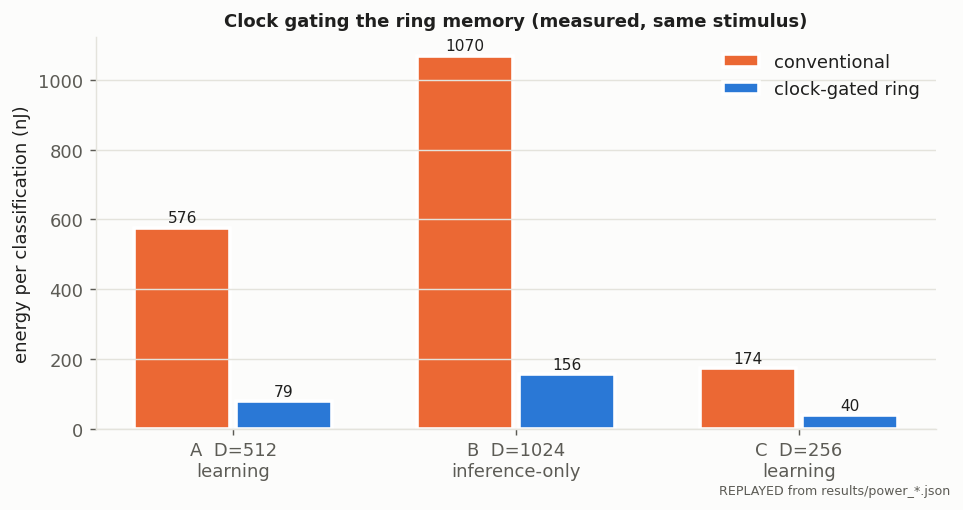

In [25]:
# @title Clock gating: power and energy (REPLAYED)
stems = {"A": "D512_P32_F64_Q16_satcomp2_L1_w2_k0", "B": "D1024_P32_F64_Q16_satcomp2_L0", "C": "D256_P32_F64_Q16_satcomp2_L1_w2_k0"}
rows, ph = [], {}
for chip, stem in stems.items():
    for tag, suffix in (("conventional", ""), ("clock-gated", "_cg")):
        j = json.load(open(f"results/power_hdc_{stem}{suffix}_clk20.json"))["phases"]; ph[(chip, tag)] = j
        for op, key in (("classify", "infer"), ("classify + learn", "learn")):
            if key in j:
                rows.append(dict(chip=chip, implementation=tag, operation=op, power_mW=j[key]["total_w"] * 1e3, energy_nJ=j[key]["energy_per_sample_nj"]))
pt = pd.DataFrame(rows)
wide = pt.pivot_table(index=["chip", "operation"], columns="implementation", values=["power_mW", "energy_nJ"])
out = pd.DataFrame({"power conv. (mW)": wide[("power_mW", "conventional")], "power gated (mW)": wide[("power_mW", "clock-gated")],
                    "energy conv. (nJ)": wide[("energy_nJ", "conventional")], "energy gated (nJ)": wide[("energy_nJ", "clock-gated")]})
out["energy saved"] = ((1 - out["energy gated (nJ)"] / out["energy conv. (nJ)"]) * 100).round(0).astype(int).astype(str) + " %"
display(out.round(1))
for chip in ("A",):
    for tag in ("conventional", "clock-gated"):
        j = ph[(chip, tag)]; print(f"chip {chip} ({tag}): one learning update = {j['learn']['energy_per_sample_nj'] - j['infer']['energy_per_sample_nj']:.0f} nJ")
gc = ph[("A", "clock-gated")]["infer"]; gg = gc["groups"]; print("\nwhere gated chip A's power goes:", {k: f"{gg[k][3] / gc['total_w']:.0%}" for k in ("Clock", "Sequential", "Combinational")})
a_, b_ = ph[("A", "clock-gated")]["infer"]["energy_per_sample_nj"], ph[("B", "clock-gated")]["infer"]["energy_per_sample_nj"]
print(f"gated A classifies with {a_ / b_ - 1:+.0%} energy vs gated B (half the dimension)")
fig, ax = plt.subplots(figsize=(7.4, 3.9)); xs = np.arange(3)
conv = [ph[(c, "conventional")]["infer"]["energy_per_sample_nj"] for c in "ABC"]; gt = [ph[(c, "clock-gated")]["infer"]["energy_per_sample_nj"] for c in "ABC"]
ax.bar(xs - 0.18, conv, 0.34, color="#eb6834", edgecolor="white", linewidth=2, label="conventional"); ax.bar(xs + 0.18, gt, 0.34, color="#2a78d6", edgecolor="white", linewidth=2, label="clock-gated ring")
for x, c, g_ in zip(xs, conv, gt):
    ax.text(x - 0.18, c + 15, f"{c:.0f}", ha="center", fontsize=8.5); ax.text(x + 0.18, g_ + 15, f"{g_:.0f}", ha="center", fontsize=8.5)
ax.set_xticks(xs, ["A  D=512\nlearning", "B  D=1024\ninference-only", "C  D=256\nlearning"]); ax.set_ylabel("energy per classification (nJ)")
ax.set_title("Clock gating the ring memory (measured, same stimulus)", fontsize=10); ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", visible=False)
fig.text(0.995, 0.005, "REPLAYED from results/power_*.json", ha="right", va="bottom", fontsize=7, color="#5c5b55"); plt.tight_layout(); plt.show()

**Is the saving real, or an artifact of the power tool?** Power analysis could in principle assume the gated clock still toggles every cycle. We checked what OpenSTA actually used for chip C: the ring's clock-gate output toggles at the rate the simulation says (about 1.4% of cycles), and the staging register's clock does not toggle at all during classification.

In [26]:
# @title Clock gating: what the power tool used (REPLAYED)
act = json.load(open("results/clock_gating_activity.json"))
print(act["design"])
print(f"main clock                       : {act['clk_port_toggles_per_s']:.2e} toggles/s")
print(f"ring clock (gated), STA used     : {act['ring_icg_GCLK_toggles_per_s']:.2e} toggles/s   (expected from the schedule: {act['expected_ring_toggles_per_s']:.2e})")
print(f"ring enable, STA used            : {act['ring_icg_GATE_toggles_per_s']:.2e} toggles/s")
print(f"staging-register clock (gated)   : {act['stage_icg_GCLK_toggles_per_s']:.2e} toggles/s   (never clocked during classification)")
print("basis:", act["expected_basis"])

chip C, clock-gated (D=256, P=32, learning), inference window of 4 real windows
main clock                       : 1.00e+08 toggles/s
ring clock (gated), STA used     : 1.38e+06 toggles/s   (expected from the schedule: 1.36e+06)
ring enable, STA used            : 1.36e+06 toggles/s
staging-register clock (gated)   : 0.00e+00 toggles/s   (never clocked during classification)
basis: 8 slice shifts per 588-cycle sample at a 100 MHz toggle rate (50 MHz clock, 2 transitions per cycle)


**Reading the results.**

* **Energy per classification falls 77 to 86% and area 23 to 28%**, with typical-corner timing slack improving by 2 to 3 ns and the slow-corner shortfall shrinking (chips A, B and C reach about 46 to 47 MHz at ss/100 C). Hold timing stays clean, and DRC and LVS are clean.
* **Gated chip A: 79 nJ per classification and 76 nJ per learning update.** It now needs 0.31 mm^2, against 0.28 mm^2 for the equally gated inference-only chip B, and still classifies with about half B's energy.
* **Why it works so well here:** the ring is the bulk of the state and is idle for 98% of cycles. A design with a busier datapath would gain less.
* **What is not gated:** the encoder accumulators, the feature memory and the control flip-flops (8 to 14% of the flip-flops) still see every clock edge. The remaining 3 to 4 mW splits into those flip-flops and their clock tree (about 70%) and the combinational logic (about 30%). Gating those, and gating the ring per word instead of as a whole, is the next step.
* **Accuracy is unchanged**: the function is identical, so every accuracy number in Sections 10 and 11 applies to the gated chips as well.

## 9. Design-space search

### 9.1 The space and the objectives

D in {256, 512, 1024, 2048} x slice width P in {32, 64, 128} x 5 similarity units x learning {off, bundle-all, error-driven} x counter width w in 2..8 x stochastic exponent k in 0..4 = **4,260 designs** (1,420 distinct accuracy configurations, since `P` never changes accuracy). Three objectives, all minimized:

1. **Error on new users after streaming**: 1 minus the accuracy on each *validation* subject's held-out windows after the chip has streamed 70% of that subject's windows test-then-train (learning-off chips stay frozen at their ideal offline prototypes). Averaged over 3 hash seeds.
2. **Area** from a surrogate fitted on real layouts.
3. **Latency** in cycles x 20 ns (computed exactly from the schedule).

Power is **not** an objective, for the reason in the next subsection.

### 9.2 The surrogate: area yes, vectorless power no

Area was fitted by ridge regression on **block-level Yosys estimates** (flip-flop storage, encoder + similarity + update logic), with leave-one-out error on the real flow rows. The model cannot be validated on its own training data, so the three final chips (not used for fitting) are a true held-out test.

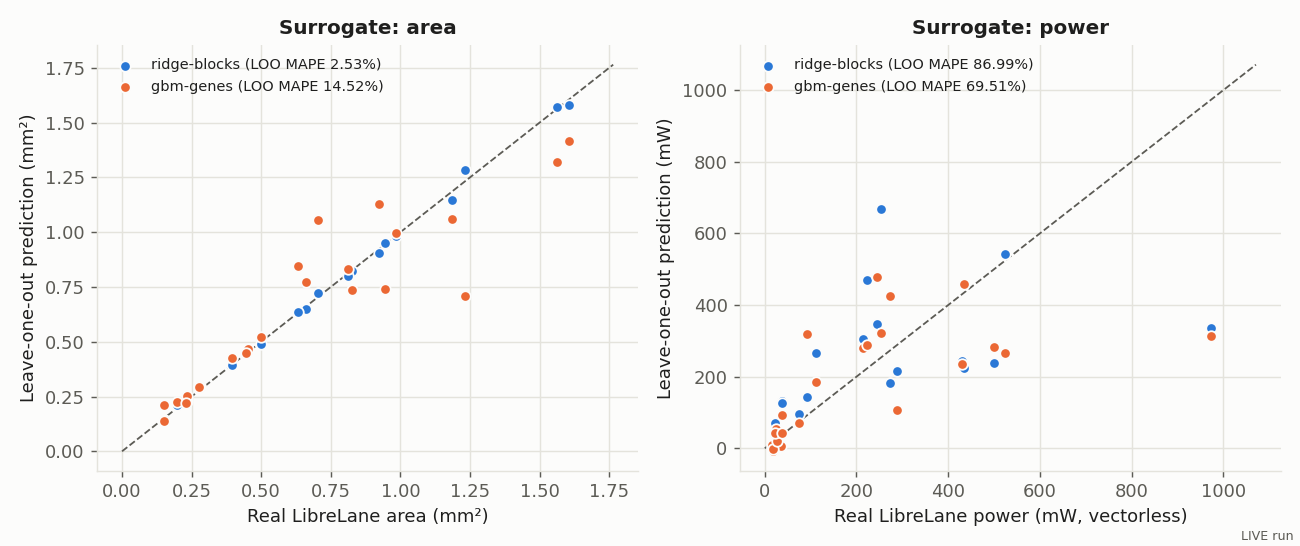

target    model       
area_mm2  gbm-genes       14.52
          ridge-blocks     2.53
power_mw  gbm-genes       69.51
          ridge-blocks    86.99


In [27]:
# @title Surrogate quality (REPLAYED)
show("day4_surrogate.png", 880)
fr0 = pd.read_csv("results/day4_surrogate_loo.csv")
print(fr0.groupby(["target", "model"]).loo_mape.first().to_string())

In [28]:
# @title Surrogate vs. real layouts for the three final chips (REPLAYED)
sp = pd.read_csv("results/day4_space.csv")
key = ["D", "P", "variant", "knob", "learn", "w", "k"]
cmp_ = fin.reset_index()[["chip", *key, "cells_mm2"]].merge(sp[key + ["area_mm2"]], on=key)
cmp_["predicted_mm2"] = cmp_.area_mm2; cmp_["error_%"] = ((cmp_.predicted_mm2 - cmp_.cells_mm2) / cmp_.cells_mm2 * 100).round(1)
display(cmp_[["chip", "D", "learn", "w", "cells_mm2", "predicted_mm2", "error_%"]].round(3))

,chip,D,learn,w,cells_mm2,predicted_mm2,error_%
0,A,512,1,2,0.426,0.418,-1.8
1,B,1024,0,8,0.394,0.390,-0.8
2,C,256,1,2,0.261,0.253,-3.0


**Area: good. Power: not.** Leave-one-out error for area is **2.5%** (ridge on block features) and the three new layouts are predicted within 1% to 3%. For vectorless power the best model has **70-87% error**: the flow's default switching activity blows up through the XOR/hash logic and bears no consistent relation to design parameters. We report that as a negative result rather than optimize against numbers we do not trust; trustworthy power comes from the activity-annotated measurement in Section 8, on the final chips. (The area surrogate describes the conventional implementation; clock gating lowers the area of the learning chips by a further 23 to 28%, measured in Section 8.3.)

### 9.3 Ground truth, and three optimizers at equal budgets

Because the space is only 4,260 points and accuracy is cheap, we **enumerated everything** to obtain the exact Pareto front (65 designs). That lets us grade search algorithms honestly: how far, in hypervolume, is each optimizer from the true front at the same number of evaluations? Random search, NSGA-II (pymoo) and Bayesian optimization (Optuna TPE, multivariate), 10 seeds each.

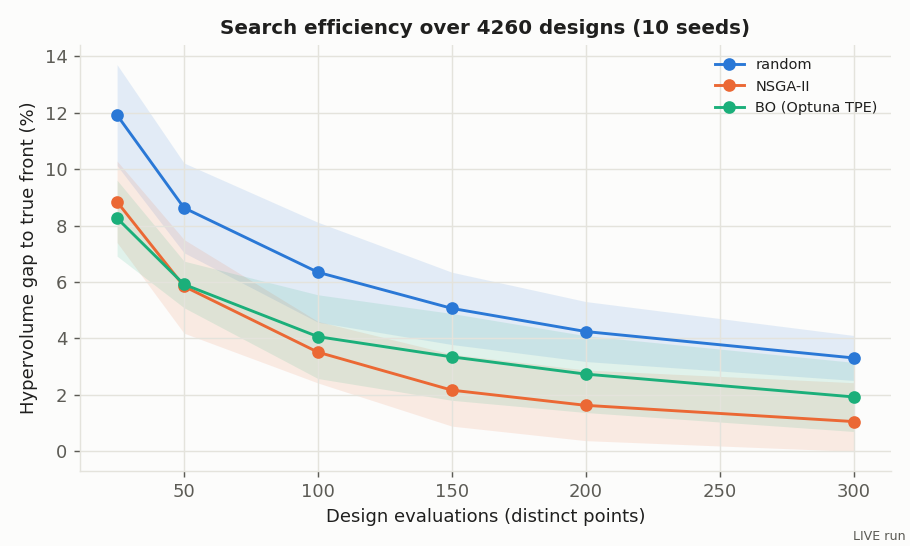

hypervolume gap to the true front (%), mean +/- std over seeds


mean                            std               
optimizer BO (Optuna TPE) NSGA-II random BO (Optuna TPE) NSGA-II random
budget                                                                 
25                    8.3     8.8   11.9             1.4     1.5    1.9
50                    5.9     5.8    8.6             0.9     1.7    1.7
100                   4.1     3.5    6.3             1.6     1.1    1.9
150                   3.3     2.2    5.1             1.6     1.3    1.4
200                   2.7     1.6    4.2             1.4     1.3    1.1
300                   1.9     1.1    3.3             1.3     1.5    0.8

In [29]:
# @title Optimizer comparison (REPLAYED)
show("day4_optimizers.png", 640)
o = pd.read_csv("results/day4_optimizers.csv")
print("hypervolume gap to the true front (%), mean +/- std over seeds")
display(o.groupby(["optimizer", "budget"]).hv_gap_pct.agg(["mean", "std"]).round(1).unstack(0))

**Reading the result.** NSGA-II and Bayesian optimization are **consistently better than random search at every budget**: at 100 evaluations NSGA-II is 3.5% from the true front and BO 4.1%, against 6.3% for random; random search needs about 300 evaluations to reach what NSGA-II reaches at 100. Between NSGA-II and BO there is no clear winner at this scale. We chose the final chips from the enumerated front and confirmed them with real flow runs.

In [30]:
# @title Optional: re-run the optimizer comparison (LIVE, 3 seeds)
if RUN_LIVE_SEARCH:
    os_, rows = None, []
    t0 = time.time()
    for name in E4s.OPTIMIZERS:
        for seed in range(3):
            rows += E4s._opt_task((name, seed))
    live = pd.DataFrame(rows); print(f"{time.time() - t0:.0f}s")
    display(live[live.budget.isin([50, 100, 300])].groupby(["optimizer", "budget"]).hv_gap_pct.agg(["mean", "std"]).round(1).unstack(0))
else:
    print("RUN_LIVE_SEARCH is False: optimizer comparison replayed from results/day4_optimizers.csv.")

RUN_LIVE_SEARCH is False: optimizer comparison replayed from results/day4_optimizers.csv.


### 9.4 The Pareto front and an interactive explorer

Each dot is one of the 4,260 designs (surrogate area, accuracy on new users after streaming); large dots are on the 3-objective Pareto front. **Bundle-all learning with very narrow counters (orange)** dominates the small-area end, error-driven learning (green) the high-accuracy end, and inference-only chips (blue) are competitive only at the smallest areas.

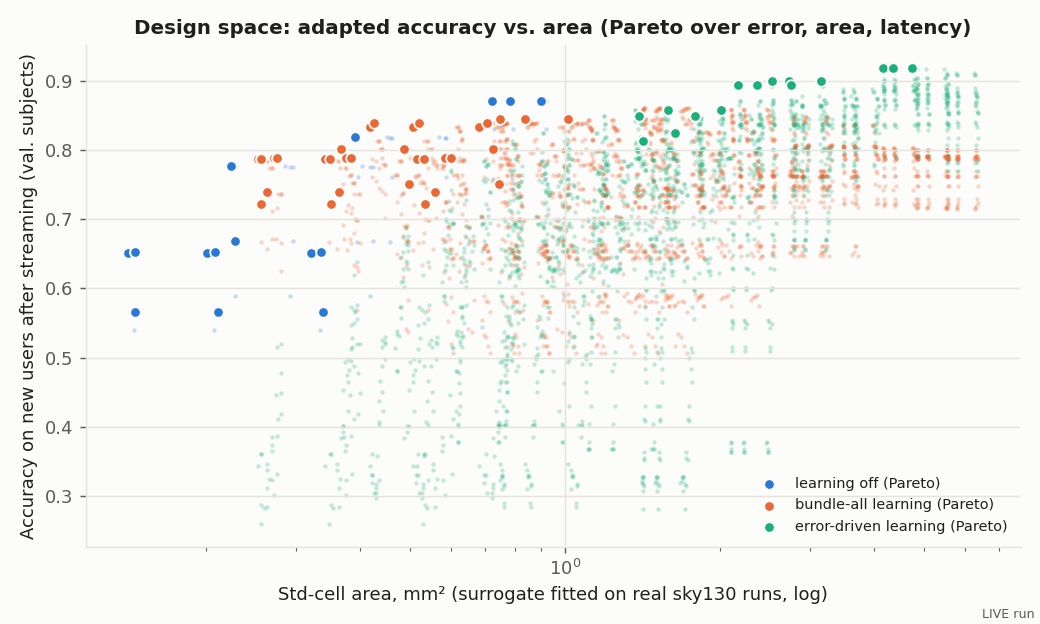

In [31]:
# @title Pareto front (REPLAYED)
show("day4_pareto.png", 880)

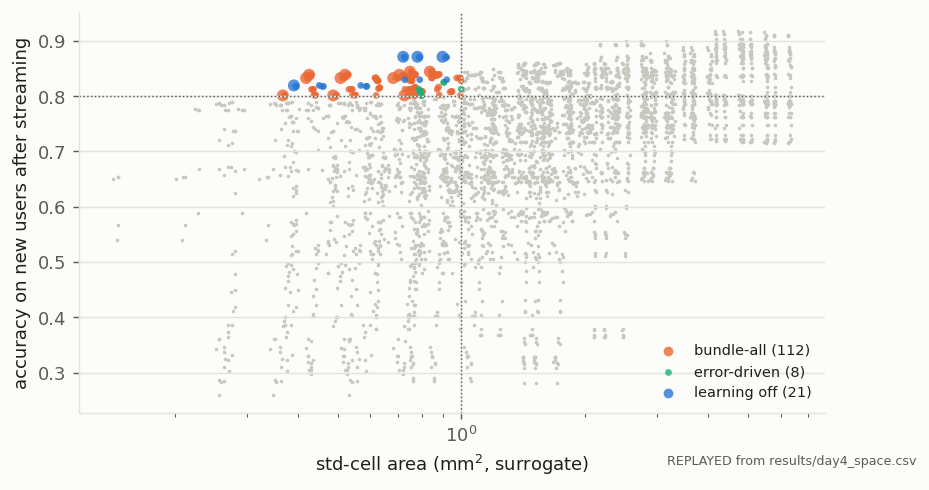

141 designs satisfy the constraints; the smallest 8:


,D,P,variant,knob,mode,w,k,acc,area_mm2,latency_us,pareto
0,256,32,satcomp,2,bundle-all,3,0,0.801,0.367,10.46,1
1,256,32,exact,0,bundle-all,3,0,0.801,0.371,10.46,0
2,256,32,satcomp,3,bundle-all,3,0,0.801,0.371,10.46,0
3,1024,32,satcomp,2,learning off,8,0,0.820,0.390,41.66,1
4,1024,32,satcomp,3,learning off,8,0,0.818,0.394,41.66,0
5,1024,32,exact,0,learning off,8,0,0.818,0.395,41.66,0
6,512,32,satcomp,2,bundle-all,2,0,0.833,0.418,20.86,1
7,512,32,satcomp,3,bundle-all,2,0,0.833,0.422,20.86,0


In [32]:
# @title Explorer: static render
import ipywidgets as W
sp["mode"] = sp.learn.map({0: "learning off", 1: "bundle-all", 2: "error-driven"})
cols = ["D", "P", "variant", "knob", "mode", "w", "k", "acc", "area_mm2", "latency_us", "pareto"]
COL = {"learning off": "#2a78d6", "bundle-all": "#eb6834", "error-driven": "#1baf7a"}

def explore(min_acc=0.80, max_area=1.0, modes=("learning off", "bundle-all", "error-driven"), max_latency=100.0):
    sel = sp[(sp.acc >= min_acc) & (sp.area_mm2 <= max_area) & sp["mode"].isin(modes) & (sp.latency_us <= max_latency)]
    fig, ax = plt.subplots(figsize=(7.4, 4))
    ax.scatter(sp.area_mm2, sp.acc, s=4, color="#c9c8c0", lw=0)
    for m, g in sel.groupby("mode"):
        ax.scatter(g.area_mm2, g.acc, s=14 + 30 * g.pareto, color=COL[m], alpha=0.8, lw=0, label=f"{m} ({len(g)})")
    ax.axhline(min_acc, color="#5c5b55", lw=0.8, ls=":"); ax.axvline(max_area, color="#5c5b55", lw=0.8, ls=":")
    ax.set_xscale("log"); ax.set_xlabel("std-cell area (mm$^2$, surrogate)"); ax.set_ylabel("accuracy on new users after streaming")
    ax.spines[["top", "right"]].set_visible(False); ax.legend(fontsize=8, frameon=False, loc="lower right")
    fig.text(0.995, 0.005, "REPLAYED from results/day4_space.csv", ha="right", va="bottom", fontsize=7, color="#5c5b55"); plt.show()
    print(f"{len(sel)} designs satisfy the constraints; the smallest 8:")
    display(sel.sort_values("area_mm2").head(8)[cols].round(3).reset_index(drop=True))

explore()      # static render (the interactive version below needs a live kernel)

In [33]:
# @title Explorer: interactive (needs a live kernel)
if os.environ.get("HDC_BATCH_EXECUTION"):
    print("Skipped during headless batch execution (widgets need a frontend). Run this cell in Colab or Jupyter to get the sliders;")
    print("the static render above shows the same plot and table for the default constraints.")
else:
    W.interact(explore,
               min_acc=W.FloatSlider(value=0.80, min=0.5, max=0.92, step=0.01, description="min acc"),
               max_area=W.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.05, description="max mm2"),
               max_latency=W.FloatSlider(value=100.0, min=1.0, max=100.0, step=1.0, description="max us"),
               modes=W.SelectMultiple(options=["learning off", "bundle-all", "error-driven"], value=("learning off", "bundle-all", "error-driven"), description="mode"));

Skipped during headless batch execution (widgets need a frontend). Run this cell in Colab or Jupyter to get the sliders;
the static render above shows the same plot and table for the default constraints.


## 10. Why learn on the chip? Three experiments

All three use the 9 test subjects with the streaming protocol of Section 4 and chips at D=1024 (exact similarity unless noted). Prototypes are trained offline on the 21 training subjects ("frozen"), loaded into the chip, and the chip then meets a new person.

### 10.1 Adapting to an unseen user

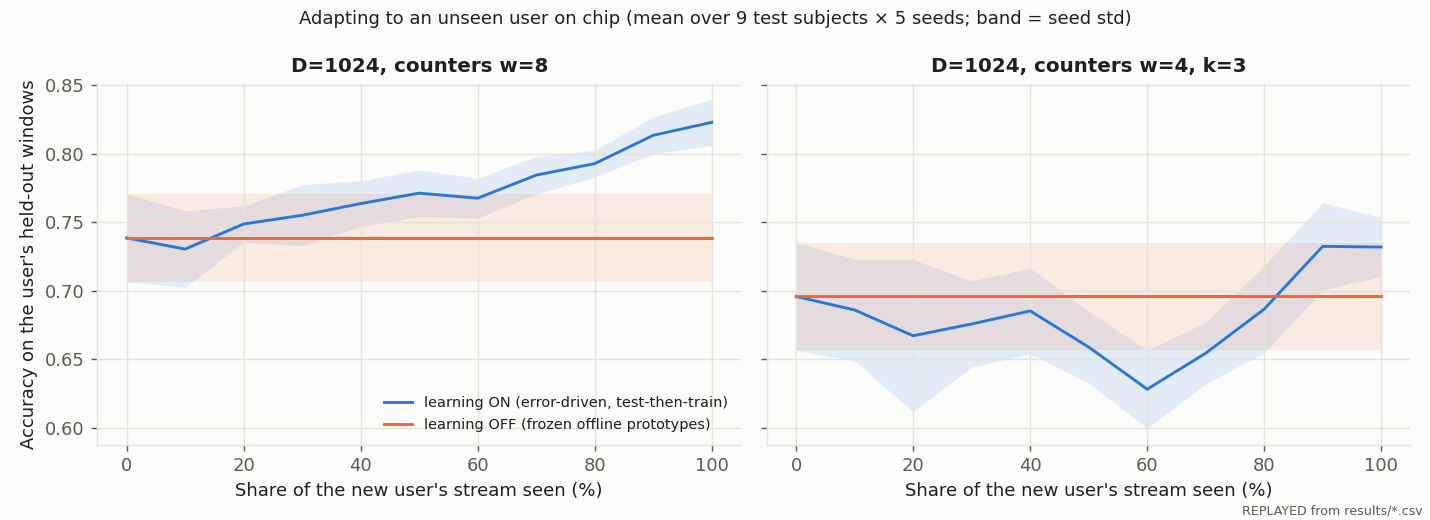

In [34]:
# @title Adaptation to a new user (REPLAYED)
E4m.plot_all(live=False); show("day4_user_adaptation.png", 900)

**Reading the figure.** With wide counters (left) the chip's accuracy on the new user's held-out windows rises from about 0.74 to about 0.82 as it streams, while the frozen chip stays flat. With 4-bit counters and stochastic updates (right) learning helps less and dips mid-stream: the stream arrives one activity at a time, which suits narrow saturating counters poorly. **Cheaper counters adapt worse**, which is the cost-accuracy trade-off the search navigates.

### 10.2 Recovering from an approximate similarity unit

Prototypes were trained with exact similarity but the chip uses an approximate unit. Does streaming recover the loss?

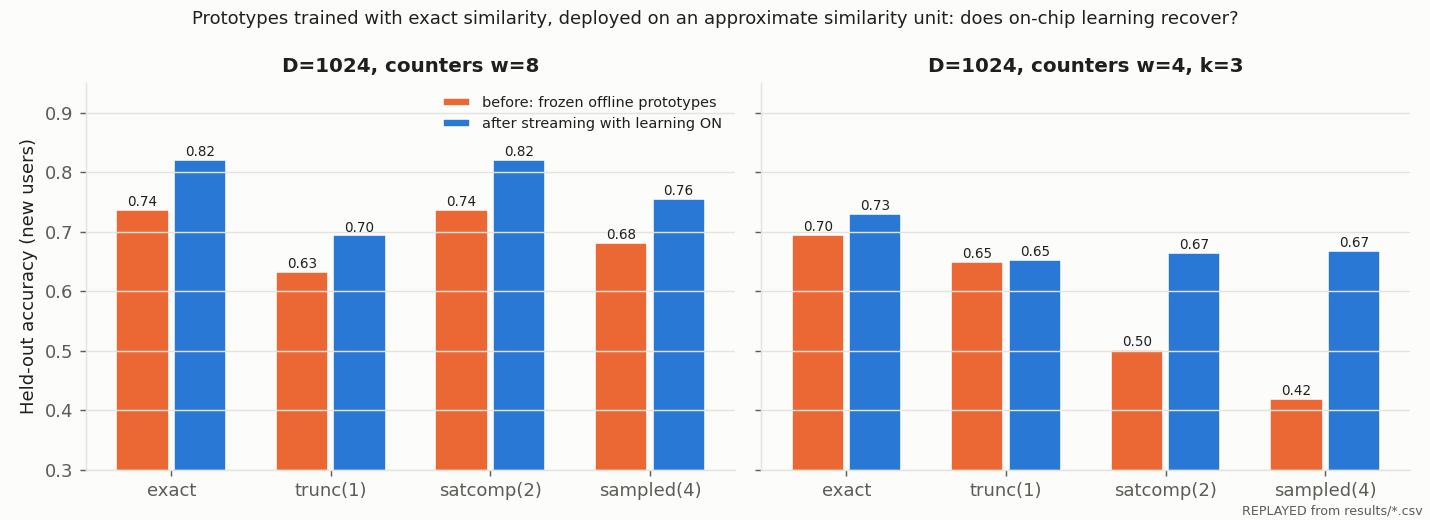

In [35]:
# @title Approximation recovery (REPLAYED)
show("day4_approx_recovery.png", 900)

**Reading the figure.** Yes, substantially: on-chip learning recovers a large part of the accuracy lost to an approximate similarity unit, in every case. The recovery is largest where the approximation hurts most (for example `sampled(4)` on 4-bit counters, 0.42 to 0.67). This is the HDC counterpart of fine-tuning after quantization.

### 10.3 Bit flips

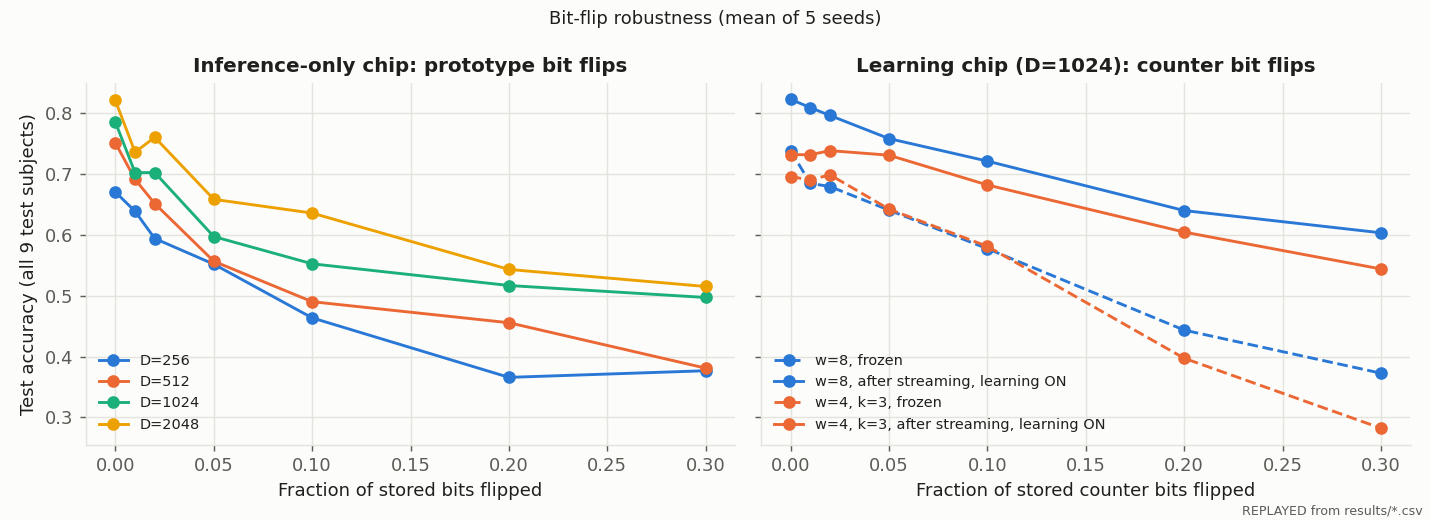

In [36]:
# @title Bit-flip robustness (REPLAYED)
show("day4_bitflips.png", 900)

**Reading the figure.** HDC's reputation for fault tolerance is only partly earned here. For an inference-only chip (left), accuracy falls steadily with stored-bit flips, more slowly for larger `D`. For a learning chip (right), flipping counter bits hurts, but **continuing to learn repairs a large part of the damage**: at 10% flipped counter bits the streaming chip retains about 0.72 versus 0.58 for a frozen one.

## 11. Final results on the 9 official test subjects

These subjects were never used for any design decision. Chips A, B and C use exactly the configurations that went through the physical flow. "Frozen" = offline prototypes only; "adapted" = after streaming 70% of the user's windows test-then-train; both evaluated on that user's held-out 30% (never learned). Mean over subjects; spread is the standard deviation over 5 hash seeds (the fabricated chips use seed 0).

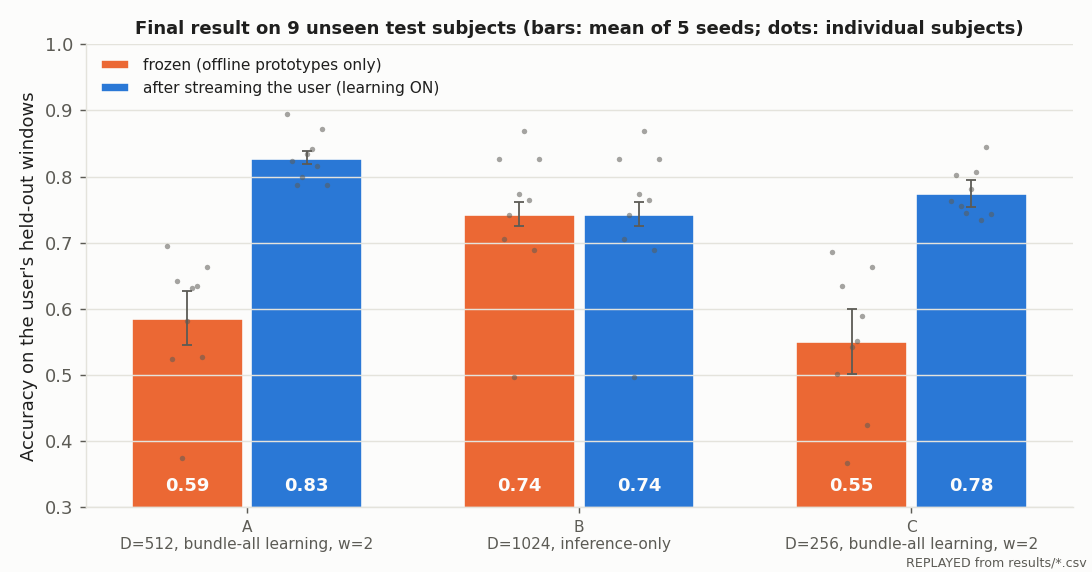


FINAL, 9 official test subjects (mean over subjects; ± std over 5 item-memory seeds; seed 0 in brackets)
chip                                    static, all windows   held-out, frozen   held-out, adapted    prequential
A  D=512, bundle-all learning, w=2      0.623±0.030 [0.638] 0.586±0.041 [0.584] 0.829±0.010 [0.834] 0.890±0.003 [0.894]
B  D=1024, inference-only               0.782±0.015 [0.801] 0.744±0.018 [0.764] 0.744±0.018 [0.764] 0.799±0.021 [0.816]
C  D=256, bundle-all learning, w=2      0.588±0.030 [0.635] 0.551±0.049 [0.589] 0.775±0.020 [0.790] 0.846±0.013 [0.865]

software reference (logistic regression, 64 features (software)): all windows 0.929, held-out 30% 0.889


In [37]:
# @title Final accuracy on unseen test users (REPLAYED)
FE.plot(live=False); show("final_test.png", 780)
FE.table()

**Reading the result.**

* **Chip A adapts from 0.59 to 0.83**, a gain of about 24 points on a person it has never seen, and ends **8 points above the bigger inference-only chip B (0.74)**, which has twice the dimension and cannot adapt. A also uses 46% less energy per classification. Its cost is 8% more area (0.43 vs 0.39 mm^2; with the clock-gated ring, 0.31 vs 0.28 mm^2 and 79 vs 156 nJ).
* Chip A's frozen accuracy is *low* (0.59): bundle-all learning with 2-bit counters is a poor offline learner. **Its value is entirely in adapting to the user**, which is what on-chip learning is for. On a validation-subject check the gap between A and B was a tie (0.83 vs 0.82); on the test subjects A pulls ahead, so we would not claim more than "at least comparable, and adaptive".
* **A software baseline is better.** A logistic regression on the same 64 quantized features reaches 0.89 on the held-out windows. HDC accelerators trade accuracy for hardware simplicity and on-chip learning; we do not claim to beat a conventional classifier, only to quantify the trade.

## 12. Limitations and what we would not claim

* **Supervised learning only.** Labels must arrive with the data (a calibration phase or feedback). Learning from the chip's own predictions (pseudo-labels) can drift and was not evaluated.
* **One dataset, one PDK, one clock.** UCI-HAR only, sky130A only, 20 ns target. Absolute areas and energies do not transfer to other nodes; ratios and trends are the claim.
* **Power is typical-corner.** Activity-annotated, but from 4 windows of one user per phase. Only the ring memory and the load staging register are clock-gated (86 to 92% of the flip-flops); the encoder accumulators, feature memory and control are not. Vectorless flow power was not used.
* **Timing is closed at the typical corner only.** The slow corner limits Fmax to about 42 to 44 MHz on the conventional chips and about 46 to 47 MHz on the clock-gated ones; we did not re-run at a relaxed clock to close it.
* **Storage is flip-flops.** An SRAM-based counter array would change the area picture; we did not try one.
* **Accuracy numbers have two origins.** Search objectives use validation subjects and a surrogate; final numbers use test subjects and real layouts; the notebook keeps them separate.
* **Colab runs a small design live, not the whole flow.** Flow results are replayed from a 34-layout CSV; one design was reproduced end to end in Colab and matched Docker to 0.01% in area.
* **No comparison with other published HDC chips**: datasets, nodes and metrics differ too much to compare honestly without re-implementing them.

## 13. Conclusion and future work

On real sky130 layouts, **on-chip learning in HDC costs 1.9x to 6.7x in area, almost all of it counter storage, and it pays back when the user is new**: a small bundle-all chip with 2-bit counters adapts to unseen users from 0.59 to 0.83 accuracy, beating a larger inference-only chip, at 541 nJ per learning update, or **76 nJ with a clock-gated ring memory**, which also shrinks the chip by about 28%. Approximating the arithmetic does little; designing the *counters*, and not clocking them when they hold, is where the leverage is. The same machinery (a bit-accurate model, a verified generator, an automated flow, an enumerable design space) is reusable for other low-power on-device learning accelerators.

**Future work:** gating the remaining flip-flops (encoder accumulators, feature memory) and the ring per word; SRAM-based counters; a second PDK (gf180) and a second dataset (for example EEG); closing timing at the slow corner; pseudo-label learning with drift control; a learned (RL) search policy; a tape-out path through a shuttle such as Tiny Tapeout for a reduced D=256 variant.

## 14. Reproducibility

| What | Where |
|---|---|
| Golden model, generator, flow wrapper, gate-level and power scripts | `src/` |
| Testbenches (cocotb), verification runner, bug-injection test | `tb/` |
| Every result table and the 34-layout flow CSV | `results/` |
| Figures (re-plotted by this notebook) | `figs/` |
| Chip A's GDS (gzip) and post-layout netlist | `artifacts/` |
| Fixed subject-wise split | `data/splits.json` |
| Tool versions, Python requirements | `versions.txt`, `requirements.txt` |

To regenerate everything: `python src/exp_day1.py`, `python src/exp_day4_model.py`, `python src/exp_day4_search.py`, `python src/final_eval.py`, `python src/flow_runner.py --batch 16` (many hours; LibreLane in Docker; add `--cg 1` for the clock-gated variants), `python tb/run_verif.py`, `python src/gls.py <flow dir> power`. Seeds are fixed; the dataset is downloaded by URL and checked against a SHA-256.

## References

1. P. Kanerva, "Hyperdimensional Computing: An Introduction to Computing in Distributed Representation with High-Dimensional Random Vectors," *Cognitive Computation* 1(2), 2009.
2. D. Anguita, A. Ghio, L. Oneto, X. Parra, J. L. Reyes-Ortiz, "A Public Domain Dataset for Human Activity Recognition Using Smartphones," *ESANN* 2013.
3. K. Deb, A. Pratap, S. Agarwal, T. Meyarivan, "A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II," *IEEE Trans. Evolutionary Computation* 6(2), 2002.
4. J. Blank, K. Deb, "pymoo: Multi-Objective Optimization in Python," *IEEE Access* 8, 2020.
5. T. Akiba, S. Sano, T. Yanase, T. Ohta, M. Koyama, "Optuna: A Next-generation Hyperparameter Optimization Framework," *KDD* 2019.
6. LibreLane (FOSSi Foundation), https://github.com/librelane/librelane. The Nix setup cells in the Colab flow test are adapted from its `notebook.ipynb` (Apache-2.0).
7. SkyWater Open Source PDK (sky130), https://github.com/google/skywater-pdk. Yosys, OpenROAD, OpenSTA, Magic, KLayout, Netgen, Verilator, Icarus Verilog, cocotb: see `versions.txt`.

**License.** Apache-2.0. Copyright 2026 the authors.